# Нейросеть как динамическая система, латентное векторное поле, его аттракторы и другие красивые слова

Привет, друзья! Меня зовут Сабрина, я XAI/MI researcher, и это наш новый туториал! В этот раз мы с вами изучим понятия дианамической системы, векторного поля и аттракторов в нем внутри автоэнкодера. 

Работать будем на основе публикации [**Navigating the Latent Space Dynamics of Neural Models**](https://arxiv.org/abs/2505.22785)
(Marco Fumero, Luca Moschella, Emanuele Rodolà, Francesco Locatello, ICLR 2026). Она попалась мне на глаза **ещё в мае 2025** и привлекла своей необычной постановкой. Сейчас, в сентябре 2026 наконец-то её описывая, я рада увидеть её принятой на ICLR 2026!

Наш план на разбор:

1. Задать определение векторного поля в общем смысле и посмотреть, что это за объект внутри модели.
2. Узнать детали поля (когда пояляется, как сходится, какие есть теоремы).
3. Узнать, что такое аттракторы, бассейны притяжения и и как найти их (вместе с тонкостями процесса). 
4. Проанализировать, как поле эволюционирует за обучение.
5. Увидеть, зачем это надо, кроме красивых картинок. 
6. Порадоваться — ведь пять шагов выше — это разбор ICLR статьи и вы его преодолели.

Шаг 6 — самый значимый. Если вы будете "трогать" термины впервые — это титанический труд — дойти до конца. Поэтому не сдавайтесь, читайте, перечитывайте и всё получится! 

Приступим. 

## **Часть 0. Сетап**

In [1]:
# ── Setup ─────────────────────────────────────────────────────────────
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

from torchvision import datasets, transforms
from scipy.stats import gaussian_kde, pearsonr
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import orthogonal_mp

# CPU специально оставим для воспроизводимости у всех и вся. GPU нам на нашей toy-жизни не нужна
DEVICE = "cpu"
plt.rcParams.update({"font.size": 10, "figure.dpi": 110})


def seed_all(s=0):
    np.random.seed(s)
    torch.manual_seed(s)


seed_all(0)
print("Ready. torch", torch.__version__)

Ready. torch 2.8.0


In [ ]:
#  Данные и модель

def load(n_train=10000, n_test=2000, fashion=False):
    '''MNIST (или FashionMNIST) в [0,1], первые n_train / n_test примеров.'''

    C = datasets.FashionMNIST if fashion else datasets.MNIST
    tr = C(root="./data", train=True, download=True, transform=transforms.ToTensor())
    te = C(root="./data", train=False, download=True, transform=transforms.ToTensor())
    Xtr = tr.data[:n_train].float().div(255.0).unsqueeze(1)
    Xte = te.data[:n_test].float().div(255.0).unsqueeze(1)

    return Xtr, tr.targets[:n_train].numpy(), Xte, te.targets[:n_test].numpy()


class AE(nn.Module):
    '''Свёрточный автоэнкодер.'''

    def __init__(self, k):
        super().__init__()
        self.k = k
        self.enc = nn.Sequential(
            nn.Conv2d(1, 32, 3, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, 2, 1), nn.ReLU(),
            nn.Flatten(), nn.Linear(64 * 7 * 7, k),
        )
        self.dec = nn.Sequential(
            nn.Linear(k, 64 * 7 * 7), nn.ReLU(), nn.Unflatten(1, (64, 7, 7)),
            nn.ConvTranspose2d(64, 32, 3, 2, 1, output_padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 3, 2, 1, output_padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.dec(self.enc(x))      # F = D ∘ E : данные в данные

    def f(self, z):
        return self.enc(self.dec(z))      # f = E ∘ D : латент в латент  


def train(model, Xtr, epochs=30, bs=128, lr=5e-4, wd=1e-4, seed=0, log=None):
    '''Adam, lr=5e-4, weight decay=1e-4 — гиперпараметры из Appendix D статьи.'''
    g = torch.Generator().manual_seed(seed)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    for ep in range(epochs):
        perm = torch.randperm(len(Xtr), generator=g)
        model.train()
        for i in range(0, len(Xtr), bs):
            b = Xtr[perm[i : i + bs]]
            loss = ((model(b) - b) ** 2).mean()
            opt.zero_grad()
            loss.backward()
            opt.step()
        if log is not None:
            log(model, ep)
    model.eval()
    return model


@torch.no_grad()
def test_mse(model, X, bs=512):
    model.eval()
    s = 0.0
    for i in range(0, len(X), bs):
        b = X[i : i + bs]
        s += ((model(b) - b) ** 2).mean(dim=(1, 2, 3)).sum().item()
    return s / len(X)


@torch.no_grad()
def iterate(model, z, n_iter=500, tol=1e-5, keep_traj=False):
    '''
    Итерация z_{t+1} = f(z_t) — уравнение (3) статьи.

    Критерий остановки взят из Appendix D: ||f(z_{t+1}) − f(z_t)||² < tol,
    либо максимум n_iter шагов. Возвращает точку остановки и число шагов
    до сходимости (n_iter, если так и не сошлось).
    '''
    model.eval()
    traj = [z.clone()] if keep_traj else None
    # steps[i] — на каком шаге i-я точка впервые удовлетворила критерию;
    # done[i] — удовлетворила ли вообще. Это только бухгалтерия для отчёта:
    # двигаться точка продолжает в любом случае (см. z = zn ниже).
    steps = torch.zeros(len(z), dtype=torch.long)
    done = torch.zeros(len(z), dtype=torch.bool)
    for t in range(n_iter):
        # Один вызов на ВЕСЬ батч точек сразу — цикла по точкам нет.
        zn = model.f(z)
        # Сравниваем с tol квадрат длины шага (Appendix D),
        newly = (~done) & (((zn - z) ** 2).sum(1) < tol)
        steps[newly] = t + 1
        done |= newly
        # Обновляются все точки, включая уже сошедшиеся. Им это не вредит:
        # они сидят в неподвижной точке и никуда не уезжают.
        z = zn
        if keep_traj:
            traj.append(z.clone())
        # Выходим по самой медленной точке батча,
        if done.all():
            break
    # Кто так и не сошёлся — помечаем  отдельно
    steps[~done] = n_iter
    return (z, steps, traj) if keep_traj else (z, steps)

def dedup(Z, thr=0.99):
    '''
    Склейка аттракторов по косинусу, как в статье: две точки остановки считаются
    одним аттрактором, если cos(z1, z2) > thr. Возвращает индексы представителей.
    '''
    S = (F.normalize(Z, dim=1) @ F.normalize(Z, dim=1).T).numpy()
    alive, keep = np.ones(len(Z), dtype=bool), []
    for i in range(len(Z)):
        if not alive[i]:
            continue
        keep.append(i)
        alive &= S[i] <= thr
        alive[i] = False
    return np.array(keep)


def euclid_groups(Z, eps):
    '''Контроль к dedup: склейка по abs евклидову порогу (single-link).'''
    return fcluster(linkage(pdist(Z.numpy()), "single"), eps, criterion="distance")


def attractor_set(Z, rel_tol=0.01):
    '''Тот же контроль, но с относительным порогом: rel_tol от медианного попарного расстояния.'''
    d = pdist(Z.numpy())
    lab = fcluster(linkage(d, "single"), rel_tol * np.median(d), criterion="distance")
    return np.array([np.where(lab == c)[0][0] for c in np.unique(lab)])


def find_attractors(model, Z0, n_iter=1000, tol=1e-12, eps=0.1):
    '''
    Опорный («щедрый») протокол: итерируем с большим запасом и очень строгим tol,
    затем склеиваем точки остановки по абсолютному порогу eps. В части 3 мы
    разберём, почему каждая из этих трёх настроек важна.
    '''
    # 1. Итерируем  стартовые точки до сходимости. n_iter здесь — не «сколько шагов
    #    сделать», а потолок — сколько максимально. В экспах хватило ~80
    zs, st = iterate(model, Z0.clone(), n_iter=n_iter, tol=tol)
    # 2. Точки остановки размазаны вокруг настоящих неподвижных точек, поэтому
    #    склеиваем их в кластеры: две точки вместе, если есть цепочка соседей ближе eps.
    lab = euclid_groups(zs, eps)
    # 3. Представитель кластера — его среднее, а не одна из точек остановки.
    A = torch.stack([zs[lab == c].mean(0) for c in np.unique(lab)])
    return A, zs, st

seed_all(0)
Xtr, ytr, Xte, yte = load(10000, 2000)
print("train", tuple(Xtr.shape), " test", tuple(Xte.shape), " values in", (Xtr.min().item(), Xtr.max().item()))

train (10000, 1, 28, 28)  test (2000, 1, 28, 28)  values in (0.0, 1.0)


## **Часть 1. Поле внутри модели**
### **1.1 Автоэнкодер и его латент**

Начнём с начала. Объектом этого туториала для нас будет автоэнкодер. 

Вспомним, что есть *автоэнкодер*. 

> Авторэнкодер $F_\Theta$ есть пара ($E_{\theta_1},  D_{\theta_2}$), где энкодер $E_{\theta_1}$ сжимает (или разжиает) вход $x$ в код $z = E(x)$, декодер $D_{\theta_2}$ восстанавливает по этому коду картинку обратно. Учится консутркция автоэнкодера так, чтобы композиция $$F = D \circ E : \mathcal{X} \to \mathcal{X}$$ могла восстановить объект $x$, то есть дать $F(x) \approx x$. Чаще всего, для этого валидно использовать MSE и для эффективности можно добавить регуляризационный член:

$$\mathcal{L}_{\mathrm{MSE}}(x) = \sum_{x \in \mathcal{X}} \|x - F_\Theta(x)\|_2^2 + \lambda R(\Theta)$$

где $R$ — явная (ограничение на параметры) или неявная (ограничение на обучение) регуляризация. 


В такой постановке у нас:
- Видно, что чтобы задать модель нужны две части
- Четко выделена компонента $z \in \mathcal{Z} \subseteq \mathbb{R}^k$, от которой зависит восстановление и упешность обучения. 

Далее нас будет интересовать именно $\mathcal{Z}$, причем всё целиком. Его назовём **латентным пространством**. Вопрос, который мы будем исследовать: как проанилизровать латентое пространство, имея в арсенали обе части модели.

**Почему нас так интересует латент?**

По постановке, латенты должны быть богаты (и в случае хорошего обучения они такие и есть). Это следствие интуиции — на основе их, сжатых/расжатых, декодер в случае успешного обучения близко восстанавливает исходный объект. И это всегда делало латетнты важным объектом анализа. 

В качестве подопытного, обучим автоэнкодер с представлением размера $k=2$ на 10 000 картинках MNIST. Такой размер скрытого представления дает нам власть строить векторное поле на плоскости в точном его виде — без сжатий и потерь информации. 

In [3]:
seed_all(0)
t0 = time.time()
ae2 = train(AE(2), Xtr, epochs=30, seed=0)
print(f"обучение k=2: {time.time() - t0:.0f} c,  test MSE = {test_mse(ae2, Xte):.5f}")

with torch.no_grad():
    Ztr2 = ae2.enc(Xtr)          # латенты обучающей выборки
print("границы латента:", Ztr2.min(0).values.tolist(), "…", Ztr2.max(0).values.tolist())

обучение k=2: 74 c,  test MSE = 0.05277
границы латента: [-49.80594253540039, -14.09279727935791] … [6.015810966491699, 42.144386291503906]


### **1.2 Привычное чтение: карта объектов**

**Стандартная постановка анализа $Z$:**

1. Поставить вопрос: как в модели кодируется "что-то"? (Выбрать, что)
2. Рассмотреть некоторые данные (сет подбирается под задачу, например разные классы, или конкретно-специфическая выборка);
3. Прогнать данные через через энкодер и снять представления для анализа;
3. Получить "след" и проанализировать его (например, объекты одного класса обычно сбиты в кластер, можно посмотреть, как одна картинка перетекает в другую, а ещё можно подвигать представления на основе направлений из разностей центроид между классами). 

Такая постановка задачи сфокусирована на том, что:
- латент определен и понимается как **карты объектов**: множество точек плюс наше описание на языке слов, направлений и центроид того, как оно себя ведет.
- объект интерпретации — расположение **конкретных данных** в модели, но не сама модель; 

Посмотрим на оба приёма сразу: где лежат классы и что модель умеет рисовать
в каждой точке плоскости.

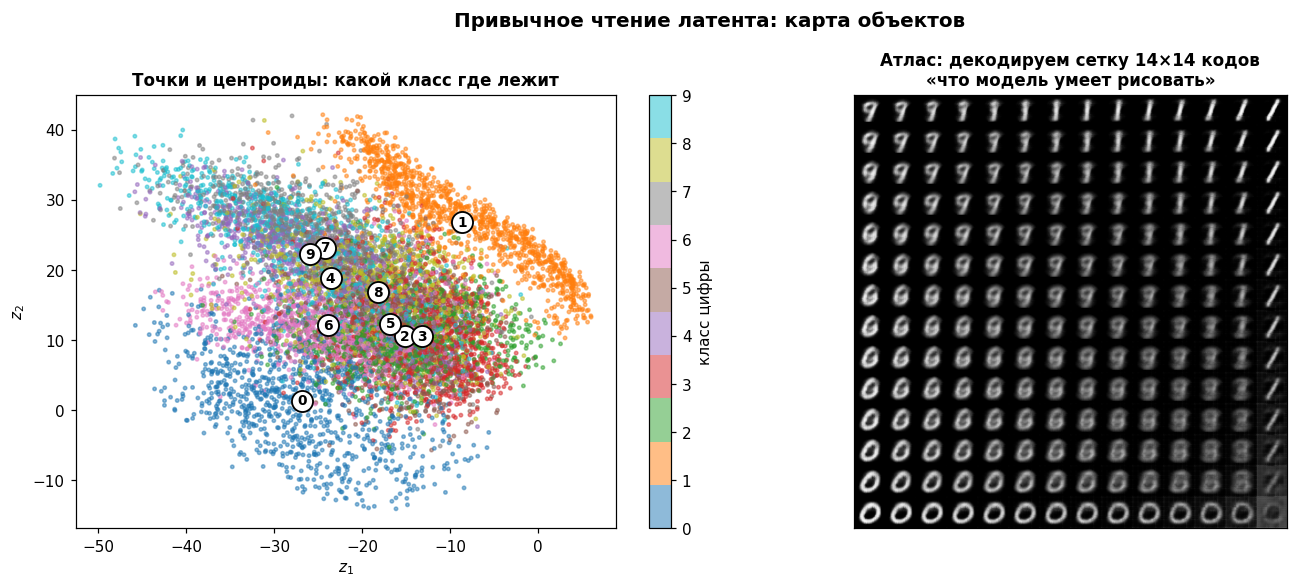

In [4]:
# ── Привычное чтение латента: карта объектов ─────────────────────────
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5.4))

# слева: где какой класс лежит + центроиды
sc = axL.scatter(Ztr2[:, 0], Ztr2[:, 1], c=ytr, cmap="tab10", s=5, alpha=0.5)
cent = np.stack([Ztr2[torch.tensor(ytr == d)].mean(0).numpy() for d in range(10)])
axL.scatter(cent[:, 0], cent[:, 1], s=190, c="white", ec="k", lw=1.2, zorder=5)
for d, (cx, cy) in enumerate(cent):
    axL.text(cx, cy, str(d), ha="center", va="center", fontsize=9, fontweight="bold", zorder=6)
axL.set_xlabel("$z_1$"); axL.set_ylabel("$z_2$")
axL.set_title("Точки и центроиды: какой класс где лежит", fontweight="bold", fontsize=11)
fig.colorbar(sc, ax=axL, ticks=range(10), label="класс цифры")

# справа: атлас — декодируем регулярную сетку кодов
n_atlas = 14
qx = np.quantile(Ztr2[:, 0].numpy(), np.linspace(0.02, 0.98, n_atlas))
qy = np.quantile(Ztr2[:, 1].numpy(), np.linspace(0.02, 0.98, n_atlas))
grid_z = torch.tensor([[x, y] for y in qy[::-1] for x in qx], dtype=torch.float32)
with torch.no_grad():
    atlas = ae2.dec(grid_z).squeeze(1).numpy()
canvas = (atlas.reshape(n_atlas, n_atlas, 28, 28)
               .transpose(0, 2, 1, 3)
               .reshape(n_atlas * 28, n_atlas * 28))
axR.imshow(canvas, cmap="gray")
axR.set_xticks([]); axR.set_yticks([])
axR.set_title(f"Атлас: декодируем сетку {n_atlas}×{n_atlas} кодов\n«что модель умеет рисовать»",
              fontweight="bold", fontsize=11)

fig.suptitle("Привычное чтение латента: карта объектов", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

- Слева. Прогоняем все 10 000 обучающих картинок через энкодер и рисуем полученные коды $z=E(x)$ точками с цветом по классу цифры, а поверх ставим центроиды — покоординатные средние кодов внутри каждого класса.

- Справа. Рассматриваем облако латентов справа. По каждой из координат берем по 14 и строим сетку из $14 \times 14$ кодов, накрывающую облако латентов (узлы расставлены по квантилям от 2-го до 98-го процентиля каждой оси). Далее декодируем каждый узел и выкладываем 196 полученных картинок в одно полотно в том же порядке — так что соседние клетки отвечают соседним точкам латента (отсюда плавный переход). 

### **1.3 Вторая композиция: $f = E \circ D$**

**Смена парадигмы: что предложила статья.** 
Постановка выше рассказала нам про расположение данных в модели, но не сказало, а что внутри себя собрала модель. Авторы [**Navigating the Latent Space Dynamics of Neural Models**](https://arxiv.org/abs/2505.22785) предлагают рассмотреть AE сам по себе, как некоторую систему, изучившую некоторую структуру. Для этого предложено изучить следующую конструкцию:


$$f(z) = E \circ D (z), \qquad f : \mathcal{Z} \to \mathcal{Z}, \quad \mathcal{Z} \subseteq \mathbb{R}^k$$


Да, энкодер от декодера. По определению — это отображение латентного пространства **в себя**, а раз это отображение в себя, то можно повторить его сколь угодно много раз: $f(f(f(\dots f(z))))$. 

<details>
<summary><b>Визуализация и проход через $D(E(x))$ </b></summary>

Запись $E \circ D$ — «энкодер от декодера» выглядит вывернутой. Визуально она устроена так:

```text
  пространство:   Z = R^k ── D ──▶   X = R^784    ── E ────▶   Z = R^k
  точка:             z    ───────▶       D(z)     ────────▶   f(z) = E(D(z))
                     └───── вышли отсюда и вернулись сюда ───────┘
```

Декодер $D : \mathcal{Z} \to \mathcal{X}$, энкодер $E : \mathcal{X} \to \mathcal{Z}$. Значит композиция $E \circ D$ начинает в $\mathcal{Z}$, уходит в $\mathcal{X}$ и возвращается обратно в $\mathcal{Z}$. Область определения и область значений отсюда — **одно и то же множество**, и только поэтому результат можно подать этой же функции на вход ещё раз.


У композиции $F = D \circ E$ типы тоже сходятся ($\mathcal{X} \to \mathcal{X}$), и её тоже можно итерировать. Это вариант классической постановки:

```text
  f = E ∘ D :  Z ──▶ X ──▶ Z     анализ в латенте*
  F = D ∘ E :  X ──▶ Z ──▶ X     анализ в (приближенных) данных 
```

</details>

Заметим, что:

- такое представление ограничено тем и только тем, что выучила внутри себя сеть и стало быть будет тем хуже, чем хуже наш AE;
- мы можем получить случай $f(f(z)) = f(z)$ (неподвижную точку). В постановке $D(E(x)) = D(z)$ у нас такие точки  скорее артефакт переобучения и как правило не возникают, а тут они — просто точки, ибо как выглядит прострнство внутри экнодера мы не знаем (и хотим узнать). 

**Неподвижные точки** будем далее обозначать как $z^* = f(z^*)$.

<details>
<summary><b> Тождественность $f$ как побочный эффект обучения. </b></summary>

Заметим, что лосс требует $D(E(x)) \approx x$. Рассмотрим фиксированную картинку $x'$ из множества тестовых данных с представлением $z' = E(x')$. Для неё по определению выполнено $D(z') \approx x'$, если модель хорошо обучена. Поставим это в исследуемую композицию $f=E(D(z)):$

$$f = E\big(D(E(x'))\big) =  E(D(z')) = \approx E(x') = z'$$

отсюда **на латентах данных обучения, валидации и теста $f$ почти тождественна.** Однако, важно зафиксировать, что:

- **«Почти» — это в точности до уровня качества модели.** Даже если уошибка реконструкции будет порядка $0.05$, то невязка, малая в начале, будет накапливаться с количеством взятия $f(z)$. 
- **На всём $E(\mathcal{X})$** остается (достаточно большое) подмножество $\mathcal{Z}$. которое никогда не появлялось в данных (и может там вообще не быть (например, ещё не придуманный шрифт MNIST-а)). На нём ничто не мешает $f$  вести себя как угодно, так как лосс туда доходил только ковсенно.

>  здесь ещё раз виден тезис — композиция $D \circ E$ — то, чему модель **училась**. Композиция $E \circ D$ нигде в лоссе не фигурирует: её поведение на латентах данных получилось как следствие, а вне данных не контролировалось.  И всё, что мы по постановке увидим в таком поле, — **побочный эффект** обучения, а не его цель.

</details>

### **1.4 Перенос набора увиденного на математическим аппарат**

Итак, у нас есть некоторое отображение в себя с последовательностью шагов. В частном случае, в математике есть часть **динамической системы**. Неформально динамическая система — это всегда множество состояний, для которых справедлив переход друг меж другом в зависимости от параметра времени (или его аналога). Формально:

>**Динамической системой**, заданной на (гладком многообразии) $X$, называется отображение $g : \mathbb{R} \times X \to X$, записываемое в параметрическом виде $g^t(x)$, где $t \in \mathbb{R}$, $x \in X$, оно дифференцируемо, и $g^0$ — тождественное отображение $X$. 

Гладкость нам нужна для диффенцируемости, а многообразие — для того чтобы видеть близость нашего $X$ к чему-то линейному. 

<details>
<summary><b> Теоретическое примечание. </b></summary>


При этом: для **стационарных обратимых** систем семейство $\{g^t : t \in \mathbb{R}\}$ образует **группу преобразований**, то есть  $g^{t_1} \circ g^{t_2} = g^{t_1 + t_2}$. Само $X$ при этом называют **фазовым пространством**, а траекторию точки под действием $g^t$ — **фазовой траекторией**.

**Стационарность** — значит, что правило движения не зависит от того, который час (который шаг): $g^t$ определяется только длительностью $t$, а не моментом старта.
**Обратимость** значит, что двигаться можно и назад, для $t > 0$.

</details>
В динамической системе допустимы "два подтипа", зависящих от формана параметра $t$. Это:  

1. **Поток** — параметр $t$ рассмотрен как непрерывное время. Это определение описывает ОДУ (обыкновенное дифференциальное уравнение)
2. **Каскад** — время идёт шагами, и система задаётся парой $(X, f)$, где $f : X \to X$. Траектория точки — последовательность $x,\ f(x),\ f^2(x), \dots$

Чтобы нанести определение на нашу задачу, декомпозируем его:

| В определении потока | У нас |
|---|---|
| фазовое пространство $X$ | латентное $\mathcal{Z} = \mathbb{R}^k$ |
| гладкое многообразие | $\mathbb{R}^k$ — многообразие, причём плоское: условие выполнено даром |
| отображение $g^t$ | $f^t = \underbrace{f \circ \dots \circ f}_{t \text{ раз}}$, где $f = E \circ D$ |
| время $t \in \mathbb{R}$ | $t \in \{0, 1, 2, \dots\}$ — сколько раз применили $f$ |
| $g^0 = \mathrm{id}$ | $f^0 = \mathrm{id}$: ноль применений ничего не меняет |
| $g^{t_1} \circ g^{t_2} = g^{t_1 + t_2}$ | $f^n \circ f^m = f^{n+m}$ — но только при $n, m \geq 0$ |
| семейство $\{g^t\}$ образует **группу** | $\{f^n\}$ образует только **полугруппу**: обратного элемента нет |
| $g$ дифференцируемо, в том числе по $t$ | Производной по времени нет, но есть производная $f$ по $z$ — якобиан $J_f$ |

Строки 1, 2, 3 и 5 и 6 совпадают. Седьмая — нет, ибо $f$ не обратима, а обратного элемента для $f$ нет по построению, так как  $E$ сминает $\mathbb{R}^{784}$ в $\mathbb{R}^k$, и разные точки после шага становятся неразличимы (нет взаимо-однозначного соответствия). 

Четвертная и восьмая расходятся же так как время дискретно, откуда отношение приращения функции к бесконечно-малому приращению аргумента ($t$) не определено (оно (приращение) у нас всегда фиксрованного размера). 

**Отсюда, когда мы работаем с преобразованиями, описаннывами выше — мы в случае каскада и работаем с дискретным временем.**

### **1.5 Шаги в пространстве: дискретное против непрерывного**


- Когда мы идем **дискретно**, мы идем прыжком на весь вектор сразу. Производной по времени нет: последовательность $z_0, z_1, z_2, \dots$ не является функцией непрерывного аргумента, и брать $\partial / \partial t$ не от чего. Её аналог — **конечная разность**:

$$\Delta z_t \;=\; z_{t+1} - z_t \;=\; f(z_t) - z_t$$

- Когда мы идем **непрерывно**, двигаясь вдоль вектора и пересчитывая направление бесконечно часто. Вот здесь производная появляется, и получается обыкновенное дифференциальное уравнение:

$$\frac{\partial z}{\partial t} \;=\; f(z) - z$$

Правые части уравнений **одинаковые** — это одно и то же поле. Отличается только левая: конечная разность против производной. Непрерывный вариант — предел дискретного при длине шага $h \to 0$, а наша итерация — противоположный край: $h = 1$, грубый шаг из возможных. Формально это метод Эйлера.

<details>
<summary><b>Кат: Метод Эйлера</b></summary>

Метод Эйлера приближает решение $\partial z / \partial t = V(z)$ так: $z(t+h) \approx z(t) + h\,V(z(t))$. Подставим $h = 1$ и $V(z) = f(z) - z$:

$$z_{t+1} \;=\; z_t + \big(f(z_t) - z_t\big) \;=\; f(z_t)$$

— что есть наша итерация, где $h = 1$ означает, что малости шага нет, и отсюда:

**Траектории разные.** Точка, прошедшая $t$ шагов итерации, — это **не** та точка, в которую её привёл бы поток за время $t$. Мы считаем ломаную, а не кривую потока. 

**А вот неподвижные точки, о которых мы ещё поговорим ниже, будут одни и те же.** Условие $V(z^*) = 0$ равносильно $f(z^*) = z^*$, никакого приближения здесь нет. То есть **пути разные, а концы совпадают** — и именно поэтому искать итерацией то, что живёт в непрерывной картинке, корректно.

</details>

Благодаря шагам, мы можем попробовать восстановить будущее каждой точки. Оъект, который его задаёт, есть вектор $V(z) \;=\; f(z) - z$, а набор всех таких векторов, по одному в каждой точке пространства, называется **векторным полем**.

**Для непрерывного времени** $V(z)$, введенный выше — это **скорость**. Он описывает, в какую сторону и как быстро она движется прямо сейчас. Будущее точки — решение уравнения $\partial z / \partial t = V(z)$: гладкая кривая, которая в каждой своей точке касается поля. Путь,
пройденный за время $t$, — это как раз $g^t(z)$ из определения выше.

**Для дискретного времени** это **приращение**: куда точка попадёт ровно за один шаг.

$$z_{t+1} \;=\; z_t + V(z_t) \;=\; f(z_t)$$

Будущее точки — последовательность $z,\ f(z),\ f^2(z), \dots$, то есть ломаная из конечных отрезков. Между узлами не происходит ничего: промежуточных положений у точки нет.

### **1.6 Неподвижные точки и аттракторы**

Заметим, что среди всех точек у нас могут быть такие, что $V(z^*) = 0$, то есть $V(z^*) = f(z^*) - z^* = 0$,
$f(z^*) = z^*$. Такие точки называют неподвижными и к ним можно прийти **с разных сторон поля**. Если траектории всех достаточно близких точек сходятся к $z^*$, будем называть её **аттрактором**.


Отлично. Определения в наших руках, и время посмотреть на них в нашем AE.Возьмём 2600 стартовых точек и поищем траектории с наивным приближением аттракторов. Для этого выполним для них итерацию $f(z) \to z$ для каждой точки. Полученные точки (куда перешел $z$ после функции) склеим по евклидовой норме 0.1 — это будут кандидаты в неподвижные точки. 

из 2600 стартовых точек получилось 2 различных неподвижных точек:
шагов до сходимости: медиана 83, максимум 111

  z*_1 = [-16.17 -10.79]   |lambda|max = 0.799   ||J||_sigma = 0.829   невязка = 1.2e-05
  z*_2 = [ 1.08 18.22]   |lambda|max = 0.576   ||J||_sigma = 0.664   невязка = 3.8e-06


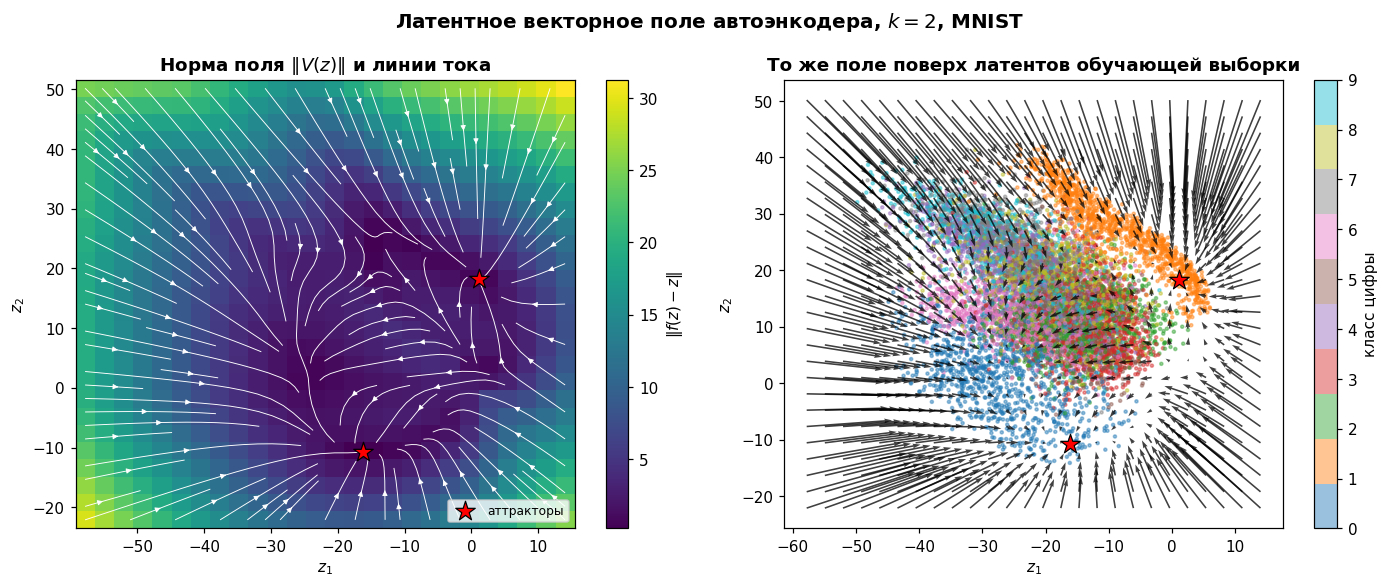

In [ ]:
# ── Векторное поле V(z) = f(z) − z ───────────────────────────────────
# Что ищем: в каждой точке z — вектор, показывающий, куда её сдвинет
# один проход через декодер и обратно через энкодер. Итерации здесь НЕТ,
# берём ровно один шаг.

# Прямоугольник, накрывающий всё облако латентов с запасом в 8 единиц:
# нам интересно и то, что происходит вне данных.
lo = (Ztr2.min(0).values - 8).numpy()
hi = (Ztr2.max(0).values + 8).numpy()


def field_grid(model, lo, hi, n):
    """Считает поле в узлах сетки n×n: возвращает координаты узлов и вектор V(z) в каждом."""
    gx, gy = np.linspace(lo[0], hi[0], n), np.linspace(lo[1], hi[1], n)
    GX, GY = np.meshgrid(gx, gy, indexing="xy")
    G = torch.tensor(np.stack([GX.ravel(), GY.ravel()], 1), dtype=torch.float32)
    with torch.no_grad():
        V = (model.f(G) - G).numpy()      # поле: один шаг f, минус исходная точка
    return GX, GY, G, V


# Грубая сетка 26×26 — для стрелок (на плотной они слипнутся в кашу).
GX, GY, G, V = field_grid(ae2, lo, hi, 26)
N = np.linalg.norm(V, axis=1).reshape(GX.shape)   # длина вектора в каждом узле → зальём цветом

# ── Аттракторы ───────────────────────────────────────────────────────
# Что ищем: точки, которые отображение f не двигает, z* = f(z*).
# Как ищем: итерируем z ← f(z) до сходимости и смотрим, где траектории
# останавливаются. Стартуем и с сетки, и с настоящих кодов данных —
# иначе рискуем не попасть в бассейн, лежащий вне облака.
GXf, GYf, Gf, _ = field_grid(ae2, lo, hi, 40)
starts = torch.cat([Gf, Ztr2[:1000]], 0)          # 1600 узлов сетки + 1000 латентов данных

# find_attractors: итерирует до шага < 1e-12 (потолок 1000 итераций — страховка),
# затем склеивает точки остановки по абсолютному евклидову порогу 0.1.
A2, zs_all, steps_all = find_attractors(ae2, starts)

print(f"из {len(starts)} стартовых точек получилось {len(A2)} различных неподвижных точек:")
print(f"шагов до сходимости: медиана {steps_all.float().median():.0f}, максимум {steps_all.max()}\n")

# Для каждой найденной точки проверяем ТРИ разные вещи:
#   |lambda|max < 1  — это аттрактор (определение 2: притягивает соседей);
#   ||J||_sigma      — выполнено ли условие СЖАТИЯ (определение 3, оно строже);
#   невязка          — действительно ли мы в неподвижной точке, а не рядом с ней.
for i, z in enumerate(A2):
    J = torch.autograd.functional.jacobian(lambda zz: ae2.f(zz.unsqueeze(0)).squeeze(0), z.clone())
    ev = torch.linalg.eigvals(J).abs().numpy()
    with torch.no_grad():
        res = (ae2.f(z.unsqueeze(0)).squeeze(0) - z).norm().item()
    print(f"  z*_{i+1} = {z.numpy().round(2)}   |lambda|max = {ev.max():.3f}   "
          f"||J||_sigma = {torch.linalg.matrix_norm(J, 2).item():.3f}   невязка = {res:.1e}")

# ── Картинка ─────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.4))

# Слева: цвет = длина вектора, белые линии = линии тока (куда потечёт при
# непрерывном движении), звёзды = найденные аттракторы.
im = ax1.pcolormesh(GX, GY, N, cmap="viridis", shading="auto")
GXs, GYs, _, Vs = field_grid(ae2, lo, hi, 40)     # линии тока рисуем по плотной сетке
ax1.streamplot(GXs[0], GYs[:, 0], Vs[:, 0].reshape(40, 40), Vs[:, 1].reshape(40, 40),
               color="white", linewidth=0.6, density=1.1, arrowsize=0.7)
ax1.scatter(A2[:, 0], A2[:, 1], s=180, marker="*", c="red", ec="k", lw=0.8, zorder=6, label="аттракторы")
ax1.set_title("Норма поля $\\|V(z)\\|$ и линии тока", fontweight="bold")
ax1.legend(loc="lower right", fontsize=8)
fig.colorbar(im, ax=ax1, label="$\\|f(z)-z\\|$")

# Справа: те же векторы стрелками поверх латентов обучающей выборки.
# angles/scale_units="xy" — длина стрелки пропорциональна НАСТОЯЩЕЙ длине
# вектора, а не отнормирована: иначе пропадёт главный эффект (поле слабое
# внутри облака данных и сильное снаружи). scale=1.6 просто укорачивает все разом.
sc = ax2.scatter(Ztr2[:, 0], Ztr2[:, 1], c=ytr, cmap="tab10", s=4, alpha=0.45)
ax2.quiver(GX, GY, V[:, 0].reshape(GX.shape), V[:, 1].reshape(GX.shape),
           angles="xy", scale_units="xy", scale=1.6, width=0.0032, color="k", alpha=0.75)
ax2.scatter(A2[:, 0], A2[:, 1], s=180, marker="*", c="red", ec="k", lw=0.8, zorder=6)
ax2.set_title("То же поле поверх латентов обучающей выборки", fontweight="bold")
fig.colorbar(sc, ax=ax2, label="класс цифры", ticks=range(10))

for ax in (ax1, ax2):
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
fig.suptitle("Латентное векторное поле автоэнкодера, $k=2$, MNIST", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

Что задает картинка:

- **Структуру.** Стрелки почти отовсюду они указывают внутрь, в область, где лежат латенты обучающих картинок. 

- **Места, где поле обнуляется (белые области).** Там $f(z) \approx z$: кодирование и декодирование перестают что-либо менять. У нашей модели таких точек **две**, и обе есть наши аттракторы по определению 2 (невязка $\|f(z^*) - z^*\|$ порядка $10^{-5}$ и $10^{-6}$).

- **Норма поля растёт с удалением от данных.** Чем дальше точка от того, что модель видела, тем сильнее её движение или, говоря иначе, длина стрелки — мера «насколько  эта точка чужая». В блоке "практическое применение" из этого следствия строят  OOD-детектор.

## **Часть 2. Почему мы сходимся к (почти) неподвижности?**

Гипотеза работы — потому что нейросети сжимающие.

> **Сжимающее** отображение — это такое, которое **сближает** любые две точки: если взять $z_1$ и
> $z_2$ и применить к ним $f$, расстояние между ними гарантированно уменьшится, причём не меньше
> чем в фиксированное число раз. Отсюда получаем сходимость: за $t$ шагов расстояние падает как $C^t$, то
> есть геометрически, и любые две траектории рано или поздно склеиваются. 

Проверить "насколько сжимающая конкретная модель в конкретной области данных" можно. Для этого нам понадобятся три определения:

### **2.1 Определения**

**Определение 1 (липшицевость).** Функция $f : \mathcal{Z} \to \mathcal{Z}$ липшицева, если существует константа $C$ такая, что для любой пары точек
$$d(f(z_1), f(z_2))_{\mathcal{Z}} \le C \, d(z_1, z_2)_{\mathcal{Z}}$$

При $C < 1$ отображение называется **сжимающим** (contractive) (то есть константа — наш первый индикатор сжимаемости)

**Определение 2 (аттрактор).** Неподвижная точка $z = f(z)$ дифференцируемого отображения $f$ называется аттрактором, если все собственные значения якобиана $J_f$ в этой точке строго меньше единицы по модулю.

**Определение 3 (константа Липшица через якобиан).** Для дифференцируемой $C$-липшицевой $f$:
$$C = \sup_{z \in \mathcal{Z}} \|J_f(z)\|_\sigma$$
где $\|\cdot\|_\sigma$ — спектральная норма (максимальное сингулярное число).

Множество стартовых условий $z_0$, приводящих к одному и тому же $z^*$, называется **бассейном притяжения** (basin of attraction).

Примечание:

- Определение 2 говорит про **собственные значения** якобиана (спектральный радиус $\rho(J)$);
- Определение 3 — про **спектральную норму** $\|J\|_\sigma$ (максимальное сингулярное число).

Для несимметричных матриц всегда $\rho(J) \le \|J\|_\sigma$, причём разрыв может быть каким угодно
большим. Практически это значит: точка может быть **аттрактором** (все $|\lambda| < 1$, траектории к ней в итоге сходятся) и при этом **не удовлетворять условию сжатия** ($\|J\|_\sigma > 1$, то есть на одном шаге расстояние может и вырасти). 

### **2.2 Почему нейросети сжимающие эмпирически**

Это связано с тем, что в обучении есть давление в сторону поведения отображения именно как
сжимающего. Статья перечисляет четыре механизма:

- **Инициализация.** Стандартные схемы (LeCun/Glorot/He) сохраняют дисперсию активаций при идеализированных допущениях — i.i.d. входы и веса. В реальности данные коррелированы, а residual-связи ломают независимость весов, и сети на инициализации оказываются смещены в сторону сжатия.

- **Явная регуляризация.** Weight decay штрафует нормы весов. Для 1-липшицевых активаций
  $\|J_\Theta(x)\|_2 \le \prod_\ell \|W_\ell\|_2 \le \prod_\ell \|W_\ell\|_F$ — то есть $L_2$-штраф напрямую давит на произведение спектральных норм (разбор этого факта в Appendix C статьи).

- **Бутылочное горлышко.** $k = \dim(\mathcal{Z})$ ограничивает ранг:
  $\mathrm{rank}(J_E) \le k$, а по цепному правилу это ограничивает и якобиан всей модели.

- **Неявная регуляризация.** Аугментации (шум в DAE, маскирование в MAE) штрафуют чувствительность к возмущениям **локально**, вокруг обучающих примеров.

Проверим первый пункт: возьмём **необученную** модель и посмотрим, что она делает с дисперсией гауссова шума в латенте (это реплика эксперимента из Appendix B.1 статьи).

In [6]:
# ── Сжимаемость на инициализации: sigma_out / sigma_in ───────────────
print("отношение дисперсий на выходе и входе f(z) = E(D(z)), необученная модель:")
print(f"{'k':>6} | {'sigma_out / sigma_in':>22}")
for k in [2, 16, 128]:
    ratios = []
    for s in range(5):                       # 5 разных инициализаций
        torch.manual_seed(100 + s)
        m = AE(k).eval()
        z = torch.randn(1000, k)
        with torch.no_grad():
            out = m.f(z)
        ratios.append((out.std() / z.std()).item())
    print(f"{k:>6} | {np.mean(ratios):>13.4f} ± {np.std(ratios):.4f}")

отношение дисперсий на выходе и входе f(z) = E(D(z)), необученная модель:
     k |   sigma_out / sigma_in
     2 |        0.0307 ± 0.0127
    16 |        0.0515 ± 0.0023
   128 |        0.0486 ± 0.0059


Отношение порядка $0.03$–$0.05$, то есть **на инициализации отображение $f$ сжимает пространство
примерно в 20–30 раз за один шаг**. В статье та же проверка сделана на 12 torchvision-бэкбонах
(Figure 6): у всех отношение меньше единицы. То есть аттрактор в свежеинициализированной сети есть
всегда, это точка около нуля, куда всё схлопывается.

Теперь посмотрим, что происходит со сжимаемостью **после** обучения. 

  на латентах обучающих данных: mean 1.086  median 1.035  max 1.800  доля значений < 1: 0.43
              далеко от данных: mean 0.361  median 0.250  max 1.723  доля значений < 1: 0.94


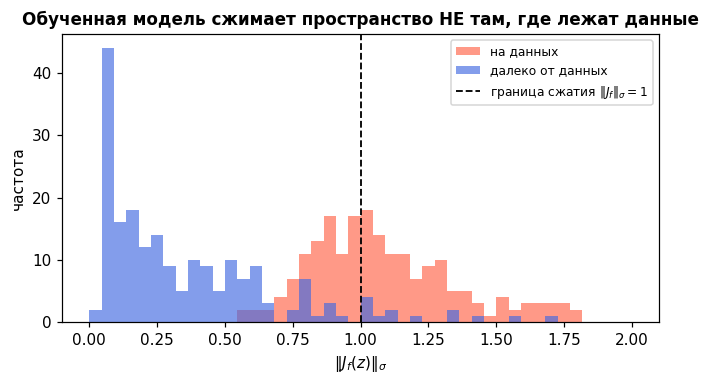

In [ ]:
#  Локальная спектральная норма якобиана у ОБУЧЕННОЙ модели 
def jac(model, z):
    '''Якобиан J_f в точке z (для k=2 это матрица 2x2, считаем точно).'''
    return torch.autograd.functional.jacobian(
        lambda zz: model.f(zz.unsqueeze(0)).squeeze(0), z.clone()
    )

def spec(J):
    return torch.linalg.matrix_norm(J, 2).item()

rs = np.random.RandomState(0)
idx = rs.choice(len(Ztr2), 200, replace=False)
on_data = np.array([spec(jac(ae2, Ztr2[i])) for i in idx])

far = torch.tensor(np.random.RandomState(1).uniform(-120, 120, size=(200, 2)), dtype=torch.float32)
off_data = np.array([spec(jac(ae2, far[i])) for i in range(200)])

for name, v in [("на латентах обучающих данных", on_data), ("далеко от данных", off_data)]:
    print(f"{name:>30}: mean {v.mean():.3f}  median {np.median(v):.3f}  "
          f"max {v.max():.3f}  доля значений < 1: {np.mean(v < 1):.2f}")

fig, ax = plt.subplots(figsize=(7, 3.4))
bins = np.linspace(0, 2.0, 45)
ax.hist(on_data, bins=bins, alpha=0.65, label="на данных", color="tomato")
ax.hist(off_data, bins=bins, alpha=0.65, label="далеко от данных", color="royalblue")
ax.axvline(1.0, color="k", ls="--", lw=1.2, label="граница сжатия $\\|J_f\\|_\\sigma = 1$")
ax.set_xlabel("$\\|J_f(z)\\|_\\sigma$"); ax.set_ylabel("частота")
ax.set_title("Обученная модель сжимает пространство не там, где лежат данные", fontweight="bold", fontsize=11)
ax.legend(fontsize=8)
plt.show()

зона                              n   медиана  доля < 1
латенты обучающей выборки     10000     1.080      0.40
рядом, но вне облака           1610     0.687      0.87
далеко (коробка ±120)          4000     0.266      0.96


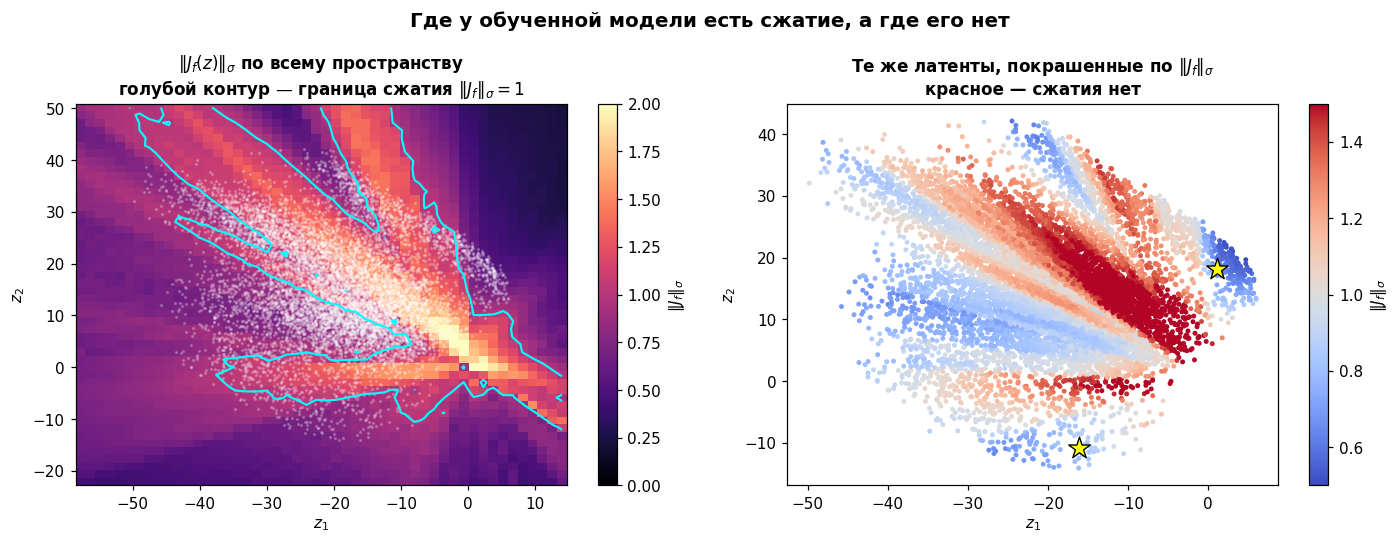

In [ ]:
# ── Карта спектральной нормы якобиана: где  нет сжатия ─────────
# Посчитаем
# ||J_f(z)||_sigma в каждом узле сетки и в каждом латенте обучающей выборки и покрасим данные. 
from torch.func import jacrev, vmap

def spec_norm_map(model, Z, chunk=2000):
    '''||J_f||_sigma сразу для пачки точек: vmap считает все якобианы разом.'''
    out = []
    jac_fn = vmap(jacrev(lambda z: model.f(z.unsqueeze(0)).squeeze(0)))
    for i in range(0, len(Z), chunk):
        J = jac_fn(Z[i : i + chunk])
        out.append(torch.linalg.matrix_norm(J, 2).detach())
    return torch.cat(out)

n_j = 50
gxj, gyj = np.linspace(lo[0], hi[0], n_j), np.linspace(lo[1], hi[1], n_j)
GXj, GYj = np.meshgrid(gxj, gyj, indexing="xy")
Gj = torch.tensor(np.stack([GXj.ravel(), GYj.ravel()], 1), dtype=torch.float32)

S_grid = spec_norm_map(ae2, Gj).numpy().reshape(n_j, n_j)   # по сетке
S_data = spec_norm_map(ae2, Ztr2).numpy()                   # в самих латентах

# Три зоны, чтобы «на данных» и «далеко от данных» не сваливались в одну кучу:
# сразу за краем облака картина уже другая, чем на дальней периферии.
rs_z = np.random.RandomState(0)
P = torch.tensor(rs_z.uniform(lo, hi, size=(4000, 2)), dtype=torch.float32)
in_bb = ((P[:, 0] > Ztr2[:, 0].min()) & (P[:, 0] < Ztr2[:, 0].max()) &
         (P[:, 1] > Ztr2[:, 1].min()) & (P[:, 1] < Ztr2[:, 1].max()))
far = torch.tensor(np.random.RandomState(1).uniform(-120, 120, size=(4000, 2)), dtype=torch.float32)

zones = [("латенты обучающей выборки", S_data),
         ("рядом, но вне облака", spec_norm_map(ae2, P[~in_bb]).numpy()),
         ("далеко (коробка ±120)", spec_norm_map(ae2, far).numpy())]
print(f'{"зона":<28} {"n":>6} {"медиана":>9} {"доля < 1":>9}')
for name, v in zones:
    print(f"{name:<28} {len(v):>6} {np.median(v):>9.3f} {np.mean(v < 1):>9.2f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 5))

im = axA.pcolormesh(GXj, GYj, S_grid, cmap="magma", shading="auto", vmin=0, vmax=2)
axA.contour(GXj, GYj, S_grid, levels=[1.0], colors="cyan", linewidths=1.4)
axA.scatter(Ztr2[:, 0], Ztr2[:, 1], s=1.5, c="white", alpha=0.20)
axA.set_title("$\\|J_f(z)\\|_\\sigma$ по всему пространству\nголубой контур — граница сжатия $\\|J_f\\|_\\sigma = 1$",
              fontweight="bold", fontsize=11)
fig.colorbar(im, ax=axA, label="$\\|J_f\\|_\\sigma$")

sc = axB.scatter(Ztr2[:, 0], Ztr2[:, 1], c=S_data, cmap="coolwarm", vmin=0.5, vmax=1.5, s=5)
axB.scatter(A2[:, 0], A2[:, 1], s=220, marker="*", c="yellow", ec="k", lw=0.9, zorder=6)
axB.set_title("Те же латенты, покрашенные по $\\|J_f\\|_\\sigma$\nкрасное — сжатия нет",
              fontweight="bold", fontsize=11)
fig.colorbar(sc, ax=axB, label="$\\|J_f\\|_\\sigma$")

for ax in (axA, axB):
    ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")
fig.suptitle("Где у обученной модели есть сжатие, а где его нет", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

Заметим, что сжимаемость не бинарна (есть или нет), а скорее непрерывна по удалению от данных:

- **На самих латентах обучающей выборки** сжатия в большинстве точек **нет**: медианная
  $\|J_f\|_\sigma \approx 1.08$, условие $< 1$ выполняется лишь в 40% точек.
- **Сразу за краем облака** оно уже появляется: медиана $\approx 0.69$, условие выполняется в 87%.
- **На дальней периферии** модель уверенно сжимающая: медиана $\approx 0.27$, условие — в 96%.

Это закономерно из обучения. На данных автоэнкодер обязан **не
терять информацию** — иначе реконструкция развалится. Отображение, сохраняющее информацию, локально
близко к изометрии, то есть $\|J_f\| \approx 1$. Сжимать до нуля модель может себе позволить только
там, где ничего ценного нет — то есть **вне** носителя данных.

> Запомним этот результат: сжатие живёт **на подходе** к данным, а не внутри них. 

## **Часть 3. Как найти аттрактор**

Выше мы нашли две неподвижные точки на основе движения: проитерировали $f(f(f(\dots f(z)\dots)))$ до остановки и склеили полученные точки по евклидовой норме. 

Наши точки получились при одном конкретном наборе: столько-то стартов, такой-то бюджет итераций, такой-то порог склейки. Если поменять любую из них — ответ может измениться и перед нами возникает вопрос — как искать оптимально?

В работе, авторы приводят следующий алгоритм (Appendix D):

1. Взять стартовые точки $z_0$ (латенты обучающих данных, латенты теста, или просто гауссов шум).
2. Итерировать $z_{t+1} = f(z_t)$, пока $\|f(z_{t+1}) - f(z_t)\|_2^2 < 10^{-6}$ (или $10^{-5}$ для
   предобученных моделей в разделах 4.1–4.2 статьи), но не более $t = 3000$ шагов (соответственно $500$).
3. Считать две точки остановки **одним и тем же** аттрактором, если
   $\cos(z_1^*, z_2^*) > 0.99$.
   
Здесь каждый из трёх шагов тоже содержит порог, который тоже повлияет на сам ответ. Обойтись без порогов на шагах поиска аттракторов мы не сможем и нас настигают ограничения:

Дедупликация по косинусу или норме полагает, что «две точки — один и тот же аттрактор, если угол/норма между ними мала». Однако в такой постановке важно помнить, что мы перенимаем также ограничения метрик:

- **Косинус не видит нормы.** Точки $(1, 0)$ и $(100, 0)$ имеют $\cos = 1$ и будут объявлены одним аттрактором, хотя 
расстояние между ними — 99. Для латентных пространств, которые почти всегда анизотропны и имеют выделенное «среднее 
направление», это значит, что аттракторы, отличающиеся в основном длиной, схлопнутся в один.

— **Норма относительна** и требует пересчета на типичную норму пространства. 

- **Порог относительный к размерности.** В $\mathbb{R}^{128}$ два
случайных вектора имеют $\cos \approx 0$, и порог $0.99$ оказывается строгим: любые две
точки остановки, различающиеся на доли процента, будут посчитаны **разными** аттракторами.
В $\mathbb{R}^2$ тот же порог — наоборот, щедрый.

- **Критерий отстановки**: $\|f(z_{t+1}) - f(z_t)\|^2 < \text{tol}$ означает «мы медленно движемся». Для линейной динамики с
коэффициентом сжатия $\rho$ остаточная ошибка связана с размером шага как $$\|z_t - z^*\| \approx \frac{\|z_{t+1} - z_t\|}{1 - \rho}$$

то есть при $\rho = 0.83$ (у наших двух аттракторов $\|J\|_\sigma$ равна $0.83$ и $0.66$) ошибка
примерно в **шесть раз** больше последнего шага. Останавливаемся мы не в аттракторе, а в облаке
вокруг него — и размер этого облака задаёт, сколько «разных» аттракторов мы потом насчитаем.

Следствие: **«число аттракторов» — это не свойство модели, это свойство 
(набор стартовых точек, ограничения на итерации, критерий склейки точек)**. Любое утверждение вида «у модели стало
больше аттракторов» осмысленно только при репорте также условий нахождения. 

И  помимо количества также полезно анализировать качество. Его нам может дать граница в виде бассейнов. 


### **3.1 Бассейны притяжения**

Вспомним, что бассейном притяжения называется множество стартовых условий $z_0$, приводящих к одному и тому же $z^*$ (basin of attraction).

доля площади на каждый бассейн: [0.7 0.3]


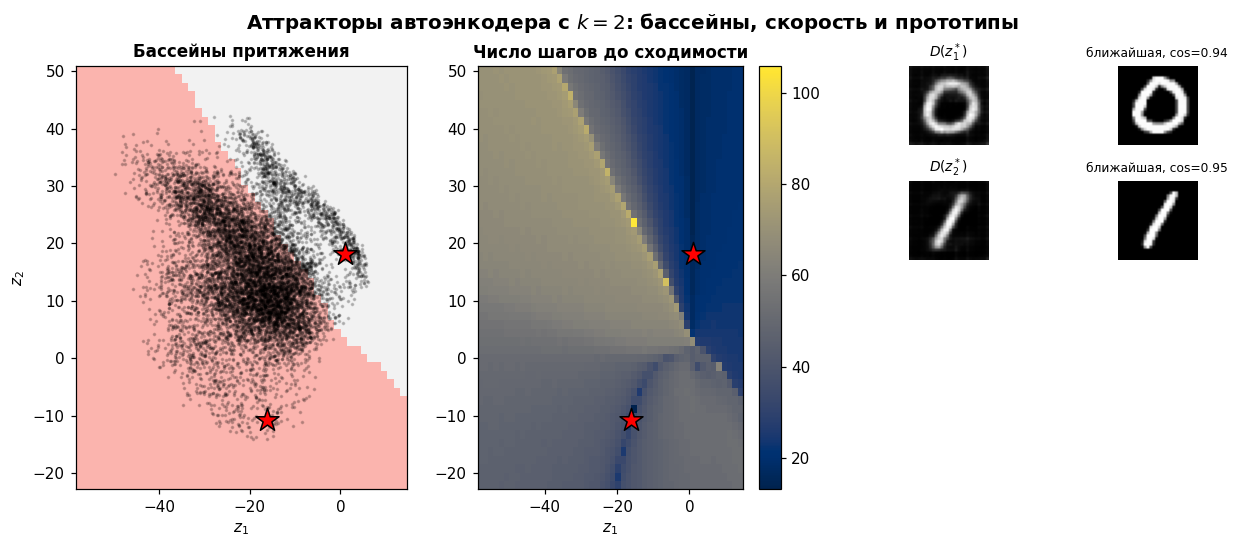

In [12]:
# ── Бассейны притяжения и декодированные аттракторы (k=2) ────────────
n_b = 50
gxb, gyb = np.linspace(lo[0], hi[0], n_b), np.linspace(lo[1], hi[1], n_b)
GXb, GYb = np.meshgrid(gxb, gyb, indexing="xy")
Gb = torch.tensor(np.stack([GXb.ravel(), GYb.ravel()], 1), dtype=torch.float32)

zb, sb = iterate(ae2, Gb.clone(), n_iter=120, tol=1e-8)

# к какому из найденных в части 1 аттракторов приезжает точка
basin = torch.cdist(zb, A2).argmin(1).numpy().reshape(n_b, n_b)
frac = np.bincount(basin.ravel(), minlength=len(A2)) / basin.size
print("доля площади на каждый бассейн:", frac.round(3))

fig = plt.figure(figsize=(13.5, 5))
gs = fig.add_gridspec(4, 4, width_ratios=[2.4, 2.4, 1, 1], hspace=0.45, wspace=0.3)

ax = fig.add_subplot(gs[:, 0])
ax.pcolormesh(GXb, GYb, basin, cmap="Pastel1", shading="auto")
ax.scatter(Ztr2[:, 0], Ztr2[:, 1], s=2, c="k", alpha=0.18)
ax.scatter(A2[:, 0], A2[:, 1], s=250, marker="*", c="red", ec="k", lw=1, zorder=6)
ax.set_title("Бассейны притяжения", fontweight="bold", fontsize=11)
ax.set_xlabel("$z_1$"); ax.set_ylabel("$z_2$")

ax = fig.add_subplot(gs[:, 1])
im = ax.pcolormesh(GXb, GYb, sb.numpy().reshape(n_b, n_b), cmap="cividis", shading="auto")
ax.scatter(A2[:, 0], A2[:, 1], s=250, marker="*", c="red", ec="k", lw=1, zorder=6)
ax.set_title("Число шагов до сходимости", fontweight="bold", fontsize=11)
ax.set_xlabel("$z_1$")
fig.colorbar(im, ax=ax)

with torch.no_grad():
    X_star = ae2.dec(A2)
n_show = min(len(A2), 4)
for i in range(n_show):
    a = fig.add_subplot(gs[i, 2])
    a.imshow(X_star[i, 0], cmap="gray"); a.axis("off")
    a.set_title(f"$D(z^*_{i+1})$", fontsize=9)

# ближайшая обучающая картинка к каждому декодированному аттрактору
Ftr_n = F.normalize(Xtr.flatten(1), dim=1)
sims = F.normalize(X_star.flatten(1), dim=1) @ Ftr_n.T
for i in range(n_show):
    a = fig.add_subplot(gs[i, 3])
    j = sims[i].argmax().item()
    a.imshow(Xtr[j, 0], cmap="gray"); a.axis("off")
    a.set_title(f"ближайшая, cos={sims[i, j]:.2f}", fontsize=8)

fig.suptitle("Аттракторы автоэнкодера с $k=2$: бассейны, скорость и прототипы",
             fontsize=13, fontweight="bold")
plt.show()

Что тут важно:

- **Граница бассейнов** достаточно резкая. То есть динамика не непрерывна по начальным условиям, что закономерно, исходя из постановки нашего шага $h=1$. Для динамических систем в простом случае такие границы валидные.  

  С точки зрения переноса нашего математического аппарата на модели это дает дает вывод о том, что характеризовать точку  ближайшим аттрактором некорректно в близости границы.  

- **Число шагов до сходимости** различно, но тоже имеет структуру. Причем быстрее сходимость там, где данных у нас мало. Это можно использовать для OOD-детекции, в статье также описано как.  

- **Декодированные аттракторы** — есть простейшие цифры ноль и единица. 

## **Часть 4. Что аттракторы помнят: память против обобщения**

Основной тезис статьи: **аттракторы — это словарь, который сеть выучила**, и по нему видно, в каком режиме находится модель. Если аттракторы совпадают с обучающими примерами — модель
**запоминает**. Если аттракторы стали абстрактными «строительными блоками» — модель **обобщает**.

### **4.1 Утверждение 3.2 из работы**

Формальная связь такая. Пусть $\mathcal{Z}^\star$ — конечный словарь аттракторов, $\Pi(z)$ —
проекция на ближайший аттрактор, а декодер $D$ липшицев с константой $L_D$. Тогда для любой тестовой
точки $x$ статья заявляет:

$$|x - F(x)\|_2^2 \;\le\; \underbrace{\|x - D(\Pi(z))\|_2^2}_{\text{ошибка прототипа}} + \underbrace{L_D^2 \|z - \Pi(z)\|_2^2}_{\text{ошибка покрытия}}$$

Смысл таков: ошибка реконструкции распадается на два члена. Первый —
**насколько хорош прототип**: близка ли декодированная версия ближайшего аттрактора к самому объекту. Второй — **насколько густо аттракторы покрывают латентное пространство**. Запоминание делает первый член нулевым на обучающих точках, но оставляет покрытие недостаточным. Обобщение требует, чтобы аттракторы
одновременно были хорошими прототипами и густо покрывали пространство.

<details>
<summary><b>Кат: в выкладке этого утверждения есть опетчатка</b></summary>

Сама выкладка (Appendix A.3) содержит опетчатку. Шаг доказательства: раскладываем

$$x - D(E(x)) = \underbrace{\big(x - D(\Pi(z))\big)}_{a} + \underbrace{\big(D(\Pi(z)) - D(E(x))\big)}_{b}$$

и дальше пишется «беря нормы и применяя неравенство Коши — Буняковского, получаем
$\|a + b\|^2 \le \|a\|^2 + \|b\|^2$».

Но раскрытие даёт

$$\|a+b\|^2 = \|a\|^2 + 2\langle a, b\rangle + \|b\|^2$$

и неравенство $\|a+b\|^2 \le \|a\|^2 + \|b\|^2$ выполняется **только если** $\langle a, b\rangle \le 0$.
Корректные варианты — либо без квадратов, по неравенству треугольника:

$$\|x - F(x)\| \;\le\; \|x - D(\Pi(z))\| + L_D \|z - \Pi(z)\|$$

либо с квадратами и множителем 2 (по неравенству $\|a+b\|^2 \le 2\|a\|^2 + 2\|b\|^2$):

$$\|x - F(x)\|^2 \;\le\; 2\|x - D(\Pi(z))\|^2 + 2 L_D^2 \|z - \Pi(z)\|^2$$

Содержательная декомпозиция «прототип + покрытие» от этого не меняется, меняется константа. Проверка — взять $a = b$, тогда

$$\|a + b\|^2 = \|2a\|^2 = 4\|a\|^2 \;>\; 2\|a\|^2 = \|a\|^2 + \|b\|^2$$

Пользоваться надо формой с множителем 2 или версией без квадратов — они верны безусловно.

> Примечание: Я проверила это неравенство и на нашей обученной модели —нарушений нет, но все же здесь также важно, что у нас простая модель. 
</details>

### **4.2 Постановка эксперимента**

Рассмотрим, как движется обучение в заивисимости от параметров. В статье авторов 30 свёрточных автоэнкодеров на CIFAR-10, MNIST и FashionMNIST, размер бутылочного горлышка
$k$ от 2 до 512, Adam с lr $5 \cdot 10^{-4}$ и weight decay $10^{-4}$, 500 эпох.

У нас: 7 автоэнкодеров на MNIST, $k \in \{2, 4, 8, 16, 32, 64, 128\}$, те же оптимизатор и
регуляризация, но 20 эпох и 10 000 обучающих картинок — чтобы всё считалось на CPU за разумное время.

Измеряем:

- **Коэффициент запоминания** $\mathrm{mem}(z^*) = \cos(D(z^*), x_{\text{ближайший}})$ — насколько
  декодированный аттрактор похож на ближайшую к нему обучающую картинку.
- **Ошибку на тесте** — стандартная мера обобщения.
- **Ранг словаря аттракторов**: число главных компонент матрицы $X^* = D(Z^*)$, объясняющих 90% дисперсии (Appendix B.5). Чем больше направлений покрывают аттракторы, тем «богаче» словарь.
- **Число различных аттракторов** — при жёстко фиксированном протоколе, как мы договорились в части 3.

> **Примечание: опечатка два** В тексте статьи коэффициент запоминания
> определён формулой $\mathrm{mem}(z^*) = \min_{x \in \mathcal{X}_{\text{train}}} \cos(D(z^*), x)$,
> а словами описан как «косинусная близость декодированного аттрактора к **ближайшей** точке
> обучающей выборки». Это разные объекты: ближайшей соответствует **максимум** косинуса, а не минимум.
> Минимум давал бы близость к самой **непохожей** картинке и не мог бы равняться отчитанным
> $0.95$–$1.0$. Мы считаем максимум — то есть по описанию.

In [ ]:
# ── Null-уровни для коэффициента запоминания ─────────────────────────
# Прежде чем радоваться высокому cos, надо знать, сколько он даёт БЕЗ всякого запоминания.
Ftr_n = F.normalize(Xtr.flatten(1), dim=1)
Fte_n = F.normalize(Xte.flatten(1), dim=1)

S = Ftr_n @ Ftr_n.T
S.fill_diagonal_(-1)
null_train = S.max(1).values.mean().item()
null_test = (Fte_n @ Ftr_n.T).max(1).values.mean().item()
g = torch.Generator().manual_seed(7)
null_noise = (F.normalize(torch.rand(500, 784, generator=g), dim=1) @ Ftr_n.T).max(1).values.mean().item()
del S

print("Сколько даёт max-косинус к обучающей выборке сам по себе:")
print(f"  обучающая картинка → ближайшая другая обучающая : {null_train:.3f}")
print(f"  тестовая картинка → ближайшая обучающая: {null_test:.3f}  (это и есть null)")
print(f"  равномерный шум → ближайшая обучающая             : {null_noise:.3f}")

Сколько даёт max-косинус к обучающей выборке САМ ПО СЕБЕ:
  обучающая картинка → ближайшая ДРУГАЯ обучающая : 0.874
  невиданная тестовая картинка → ближайшая обучающая: 0.856   ← вот это и есть null
  равномерный шум → ближайшая обучающая             : 0.519


Зачем нам нужны нули? **Произвольная** картинка MNIST имеет косинус $\approx 0.86$ к ближайшей обучающей, так как MNIST-цифры простые (белые штрихи на чёрном фоне), все значения неотрицательны, и косинус между любыми двумя картинками структурно высок. Даже равномерный шум даёт $\approx 0.52$.

Поэтому анализировать мы будем **разность** с этим уромнем и 
**сравнение между моделями**. 

In [16]:
# ── Sweep по размеру бутылочного горлышка ────────────────────────────
def mem_coeff(Xstar):
    '''max-косинус декодированного аттрактора к ближайшей обучающей картинке.'''
    return (F.normalize(Xstar.flatten(1), dim=1) @ Ftr_n.T).max(1).values


def rank90(Xstar):
    '''Сколько главных компонент словаря аттракторов объясняют 90% дисперсии.'''
    M = Xstar.flatten(1).numpy()
    s = np.linalg.svd(M - M.mean(0), compute_uv=False)
    return int(np.searchsorted(np.cumsum(s ** 2) / np.sum(s ** 2), 0.90) + 1)


KS = [2, 4, 8, 16, 32, 128]
rows, models = [], {}
t_all = time.time()
for k in KS:
    t0 = time.time()
    seed_all(0)
    m = train(AE(k), Xtr, epochs=20, seed=0)
    with torch.no_grad():
        Z0 = m.enc(Xtr[:300])
    zs_k, steps_k = iterate(m, Z0.clone(), n_iter=200, tol=1e-5)
    with torch.no_grad():
        Xstar = m.dec(zs_k)
    mc = mem_coeff(Xstar)
    rows.append(dict(k=k, test_mse=test_mse(m, Xte), mem=mc.mean().item(), mem_sd=mc.std().item(),
                     n_cos=len(dedup(zs_k, 0.99)), n_euc=len(attractor_set(zs_k, 0.01)),
                     rank90=rank90(Xstar), steps_med=float(steps_k.float().median())))
    models[k] = m
    print(f"k={k:>3}  {time.time()-t0:>5.0f} c  " +
          "  ".join(f"{a}={rows[-1][a]:.3f}" if isinstance(rows[-1][a], float) else f"{a}={rows[-1][a]}"
                    for a in ["test_mse", "mem", "n_cos", "rank90"]), flush=True)

df = pd.DataFrame(rows)
print(f"\nвсего {time.time()-t_all:.0f} c\n")
print(df.round(4).to_string(index=False))

k=  2     49 c  test_mse=0.054  mem=0.938  n_cos=3  rank90=2
k=  4     52 c  test_mse=0.042  mem=0.952  n_cos=6  rank90=2
k=  8     54 c  test_mse=0.026  mem=0.534  n_cos=8  rank90=3
k= 16     50 c  test_mse=0.015  mem=0.532  n_cos=34  rank90=5
k= 32     53 c  test_mse=0.008  mem=0.261  n_cos=5  rank90=2
k=128     52 c  test_mse=0.005  mem=0.202  n_cos=1  rank90=2

всего 311 c

  k  test_mse    mem  mem_sd  n_cos  n_euc  rank90  steps_med
  2    0.0537 0.9376  0.0088      3     37       2       31.0
  4    0.0416 0.9517  0.0220      6     56       2      142.0
  8    0.0264 0.5342  0.1281      8     11       3      121.0
 16    0.0152 0.5322  0.1866     34     94       5      127.0
 32    0.0085 0.2607  0.0750      5      5       2       50.0
128    0.0055 0.2020  0.0000      1    300       2       26.0


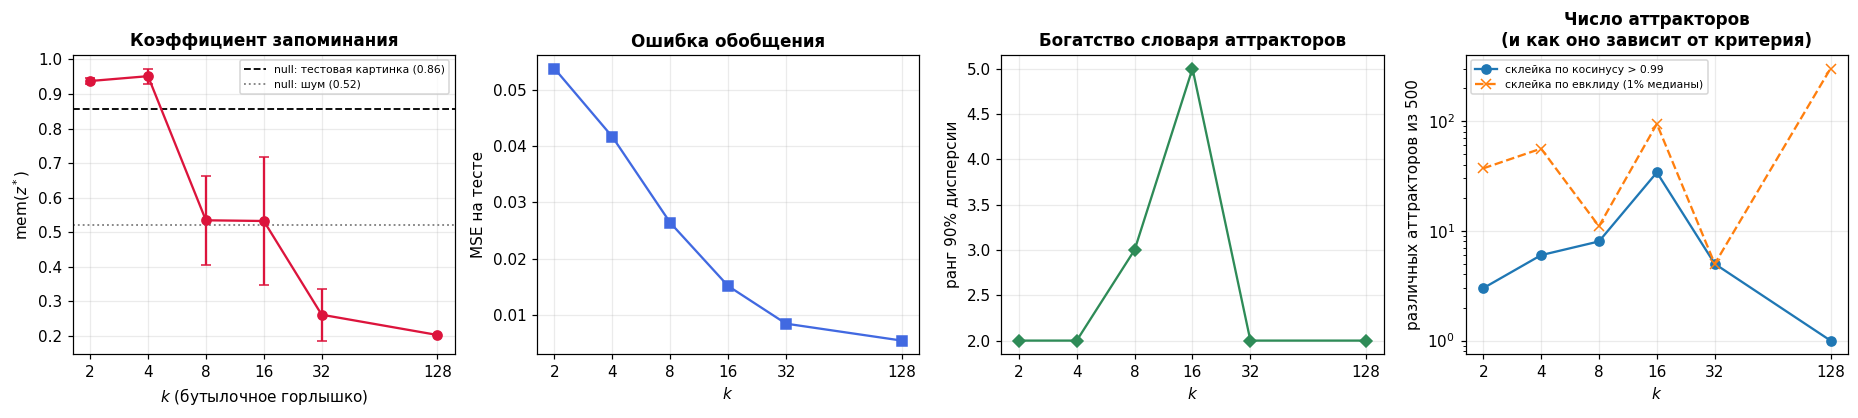

In [17]:
# ── Картинка: память против обобщения (реплика Figure 2 статьи) ──────
fig, axes = plt.subplots(1, 4, figsize=(17, 3.9))

ax = axes[0]
ax.errorbar(df.k, df.mem, yerr=df.mem_sd, marker="o", capsize=3, color="crimson")
ax.axhline(null_test, ls="--", c="k", lw=1.2, label=f"null: тестовая картинка ({null_test:.2f})")
ax.axhline(null_noise, ls=":", c="gray", lw=1.2, label=f"null: шум ({null_noise:.2f})")
ax.set_xscale("log", base=2); ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_xlabel("$k$ (бутылочное горлышко)"); ax.set_ylabel("$\\mathrm{mem}(z^*)$")
ax.set_title("Коэффициент запоминания", fontweight="bold", fontsize=11)
ax.legend(fontsize=7); ax.grid(alpha=0.25)

ax = axes[1]
ax.plot(df.k, df.test_mse, marker="s", color="royalblue")
ax.set_xscale("log", base=2); ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_xlabel("$k$"); ax.set_ylabel("MSE на тесте")
ax.set_title("Ошибка обобщения", fontweight="bold", fontsize=11); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(df.k, df.rank90, marker="D", color="seagreen")
ax.set_xscale("log", base=2); ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_xlabel("$k$"); ax.set_ylabel("ранг 90% дисперсии")
ax.set_title("Богатство словаря аттракторов", fontweight="bold", fontsize=11); ax.grid(alpha=0.25)

ax = axes[3]
ax.plot(df.k, df.n_cos, marker="o", label="склейка по косинусу > 0.99")
ax.plot(df.k, df.n_euc, marker="x", ls="--", label="склейка по евклиду (1% медианы)")
ax.set_xscale("log", base=2); ax.set_yscale("log"); ax.set_xticks(KS); ax.set_xticklabels(KS)
ax.set_xlabel("$k$"); ax.set_ylabel("различных аттракторов из 500")
ax.set_title("Число аттракторов\n(и как оно зависит от критерия)", fontweight="bold", fontsize=11)
ax.legend(fontsize=7); ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

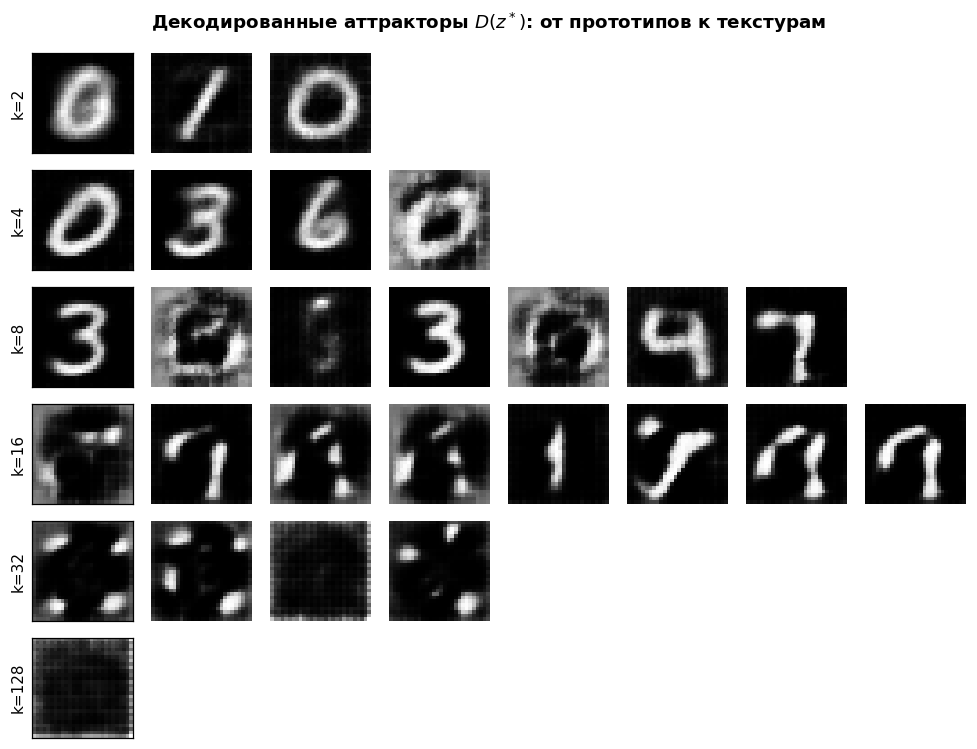

In [18]:
# ── Как выглядят сами аттракторы при разном k ────────────────────────
fig, axes = plt.subplots(len(KS), 8, figsize=(9, 1.15 * len(KS)))
for r, k in enumerate(KS):
    m = models[k]
    with torch.no_grad():
        Z0 = m.enc(Xtr[:100])
    zs_k, _ = iterate(m, Z0.clone(), n_iter=200, tol=1e-5)
    keep = dedup(zs_k, 0.99)[:8]
    with torch.no_grad():
        Xs = m.dec(zs_k[keep])
    for c in range(8):
        ax = axes[r, c]; ax.axis("off")
        if c < len(keep):
            ax.imshow(Xs[c, 0], cmap="gray")
    axes[r, 0].set_ylabel(f"k={k}")
    axes[r, 0].axis("on"); axes[r, 0].set_xticks([]); axes[r, 0].set_yticks([])
fig.suptitle("Декодированные аттракторы $D(z^*)$: от прототипов к текстурам", fontweight="bold")
fig.tight_layout()
plt.show()

**Результаты**

**Главный тезис статьи воспроизвёлся.** Коэффициент запоминания падает с ростом $k$
($0.94 \to 0.95 \to 0.53 \to 0.53 \to 0.26 \to 0.20$), а ошибка на тесте падает монотонно
($0.054 \to 0.0055$). Размен «сильнее регуляризация — больше запоминания и хуже обобщение» виден
ровно так, как в Figure 2 статьи.

**Учитывая нули,** выше уровня прозивольной тестовой картинки ($0.856$)
оказались только $k=2$ и $k=4$. Уже при $k=8$ коэффициент падает до $0.53$ — это уровень
**равномерного шума** ($0.519$), а при $k=32$ и $k=128$ он опускается **ниже** шумового уровня.

То есть корректная формулировка — не "аттракторы стали обобщёнными признаками", а "декодированные
аттракторы перестали быть похожи на MNIST". Картинка с аттракторами это подтверждает: от
узнаваемых прототипов при $k=2$ к однородным пятнам при больших $k$. Но на практике это может быть сигналом обобщения в том числе. 

**Число аттракторов скачет.** По косинусу: $3, 6, 8, 34, 5, 1$.
По евклиду: $37, 56, 11, 94, 5, 300$. Обратите внимание на $k=128$: **1 против 300**. Все триста
точек остановки различны по евклидову расстоянию и при этом попарно имеют $\cos > 0.99$ — то есть
лежат почти на одном луче и отличаются в основном длиной. Это есть разночтение метрик. 

**Ранг словаря аттракторов** ($2, 2, 3, 5, 2, 2$) не даёт монотонного роста 
(показанного в Appendix B.5).

**Гипотезы.** Простой эксперимент учим 20 эпох на 10 000 картинках; в статье — 500 эпох на полных датасетах.
Возможно, наше поле просто слишком простое, отображение $f$ осталось близким к своему
сильно-сжимающему начальному состоянию. Проверим её напрямую — для $k=128$, на 50 эпох.

In [19]:
# ── Насколько поле зависит от бюджета обучения ───────────────────────
seed_all(0)
ae128_long = train(AE(128), Xtr, epochs=50, seed=0)

comp = []
for name, m in [("k=128, 20 эпох", models[128]), ("k=128, 50 эпох", ae128_long)]:
    with torch.no_grad():
        Z0 = m.enc(Xtr[:300])
    zs_c, st_c = iterate(m, Z0.clone(), n_iter=200, tol=1e-5)
    with torch.no_grad():
        Xs_c = m.dec(zs_c)
    comp.append(dict(модель=name, test_mse=round(test_mse(m, Xte), 4),
                     mem=round(mem_coeff(Xs_c).mean().item(), 3),
                     по_косинусу=len(dedup(zs_c, 0.99)), по_евклиду=len(attractor_set(zs_c, 0.01)),
                     ранг90=rank90(Xs_c), шагов_медиана=int(st_c.float().median())))
print(pd.DataFrame(comp).to_string(index=False))

        модель  test_mse   mem  по_косинусу  по_евклиду  ранг90  шагов_медиана
k=128, 20 эпох    0.0055 0.202            1         300       2             26
k=128, 50 эпох    0.0040 0.298           28         300       7             63


Гипотеза подтвердилась. За 30 дополнительных эпох:

- число косинус-различных аттракторов выросло с **1 до 28**;
- ранг словаря — с **2 до 7**;
- медианное число шагов до сходимости — с **26 до 63**, то есть отображение стало заметно
  **менее** сжимающим.

Значит, вырожденность нашего поля — следствие бюджета обучения.
А евклидов счёт как был 300, так и остался: он насыщен с самого начала и меряет разброс точек
остановки, а не структуру поля.

> **Практический вывод.** Прежде чем что-либо говорить про
> аттракторы модели, надо убедиться, что поле  нетривиально. Самая простая проверка —
> **медианное число шагов до сходимости**: если это 26 шагов из 200, вы смотрите не на богатую
> динамику, а на почти постоянное отображение, и любые выводы про «словарь признаков» будут
> выводами про одну точку.

## **Часть 5. Как поле рождается по ходу обучения**

До сих пор мы сравнивали **разные** модели. Статья показывает (Figure 3), что тот же переход
«запоминание → обобщение» происходит и внутри **одной** модели по ходу обучения. Тезисы такие :

1. На инициализации аттрактор ровно один — всё схлопывается в начало координат (мы это измерили
   в части 2: $\sigma_{\text{out}}/\sigma_{\text{in}} \approx 0.04$).
2. В первые эпохи модель **запоминает**: коэффициент запоминания высокий, тестовая ошибка большая.
3. Дальше коэффициент запоминания падает, тестовая ошибка падает тоже, число различных аттракторов
   растёт и выходит на плато.
4. Аттракторы, посчитанные **из шума**, постепенно сближаются с аттракторами, посчитанными из
   обучающих данных, — то есть словарь становится одним и тем же, откуда ни стартуй.
5. Но **траектории** к этим аттракторам остаются различимыми. Именно поэтому потом работает
   OOD-детекция: аттрактор один и тот же, путь к нему — разный.

Повторим все пять пунктов на модели с $k = 64$, логируя статистики каждые 5 эпох.

In [21]:
# ── Инструменты для траекторий (пригодятся и в части 6) ──────────────
@torch.no_grad()
def traj_score(model, Z0, A_star, n_iter=30):
    '''
    score(z) = (1/N) * sum_t d(z_t, Z*_train) — средняя по траектории дистанция
    до множества обучающих аттракторов (формула из раздела 4.2 статьи).
    '''
    model.eval()
    z, acc = Z0.clone(), torch.zeros(len(Z0))
    for _ in range(n_iter):
        acc += torch.cdist(z, A_star).min(1).values
        z = model.f(z)
    return (acc / n_iter).numpy()


def chamfer_cos(A, B):
    '''Симметричная косинусная близость двух множеств точек (Chamfer).'''
    S = F.normalize(A, dim=1) @ F.normalize(B, dim=1).T
    return 0.5 * (S.max(1).values.mean() + S.max(0).values.mean()).item()


def fpr_at_95tpr(s_id, s_ood):
    '''Доля OOD-объектов, принятых за свои, при пороге, пропускающем 95% своих.'''
    return float((s_ood <= np.quantile(s_id, 0.95)).mean())

In [22]:
# ── Динамика обучения (реплика Figure 3 статьи) ──────────────────────
seed_all(0)
ae64 = AE(64)
noise_img = torch.rand(150, 1, 28, 28, generator=torch.Generator().manual_seed(11))
hist = []

def log_step(model, ep):
    if ep % 5 and ep != 0:
        return
    model.eval()
    with torch.no_grad():
        Ztr0, Zte0, Zn0 = model.enc(Xtr[:150]), model.enc(Xte[:150]), model.enc(noise_img)
    A_tr, _ = iterate(model, Ztr0.clone(), 80, 1e-5)
    A_te, _ = iterate(model, Zte0.clone(), 80, 1e-5)
    A_n, _ = iterate(model, Zn0.clone(), 80, 1e-5)
    with torch.no_grad():
        Xs = model.dec(A_tr)
    A_uniq = A_tr[dedup(A_tr, 0.99)]
    hist.append(dict(
        ep=ep, test=test_mse(model, Xte), mem=mem_coeff(Xs).mean().item(),
        n_tr=len(dedup(A_tr, 0.99)) / 150, n_te=len(dedup(A_te, 0.99)) / 150,
        n_noise=len(dedup(A_n, 0.99)) / 150, cham=chamfer_cos(A_tr, A_n),
        fpr95=fpr_at_95tpr(traj_score(model, Ztr0, A_uniq), traj_score(model, Zn0, A_uniq)),
    ))
    print({a: (round(v, 4) if isinstance(v, float) else v) for a, v in hist[-1].items()}, flush=True)
    model.train()

t0 = time.time()
train(ae64, Xtr, epochs=31, seed=0, log=log_step)
dyn = pd.DataFrame(hist)
print(f"\n{time.time()-t0:.0f} c")

{'ep': 0, 'test': 0.065, 'mem': 0.9196, 'n_tr': 0.0067, 'n_te': 0.0067, 'n_noise': 0.0067, 'cham': 1.0, 'fpr95': 0.0}
{'ep': 5, 'test': 0.0117, 'mem': 0.2292, 'n_tr': 0.0067, 'n_te': 0.0067, 'n_noise': 0.0133, 'cham': 0.9996, 'fpr95': 0.14}
{'ep': 10, 'test': 0.0076, 'mem': 0.2348, 'n_tr': 0.0867, 'n_te': 0.1067, 'n_noise': 0.08, 'cham': 0.9956, 'fpr95': 0.9133}
{'ep': 15, 'test': 0.0062, 'mem': 0.1931, 'n_tr': 0.0467, 'n_te': 0.06, 'n_noise': 0.0133, 'cham': 0.9924, 'fpr95': 1.0}
{'ep': 20, 'test': 0.0056, 'mem': 0.5234, 'n_tr': 0.4733, 'n_te': 0.4333, 'n_noise': 0.06, 'cham': 0.8072, 'fpr95': 1.0}
{'ep': 25, 'test': 0.0051, 'mem': 0.236, 'n_tr': 0.1867, 'n_te': 0.1667, 'n_noise': 0.0067, 'cham': 0.9673, 'fpr95': 1.0}
{'ep': 30, 'test': 0.0049, 'mem': 0.1744, 'n_tr': 0.02, 'n_te': 0.04, 'n_noise': 0.0067, 'cham': 0.997, 'fpr95': 1.0}

97 c


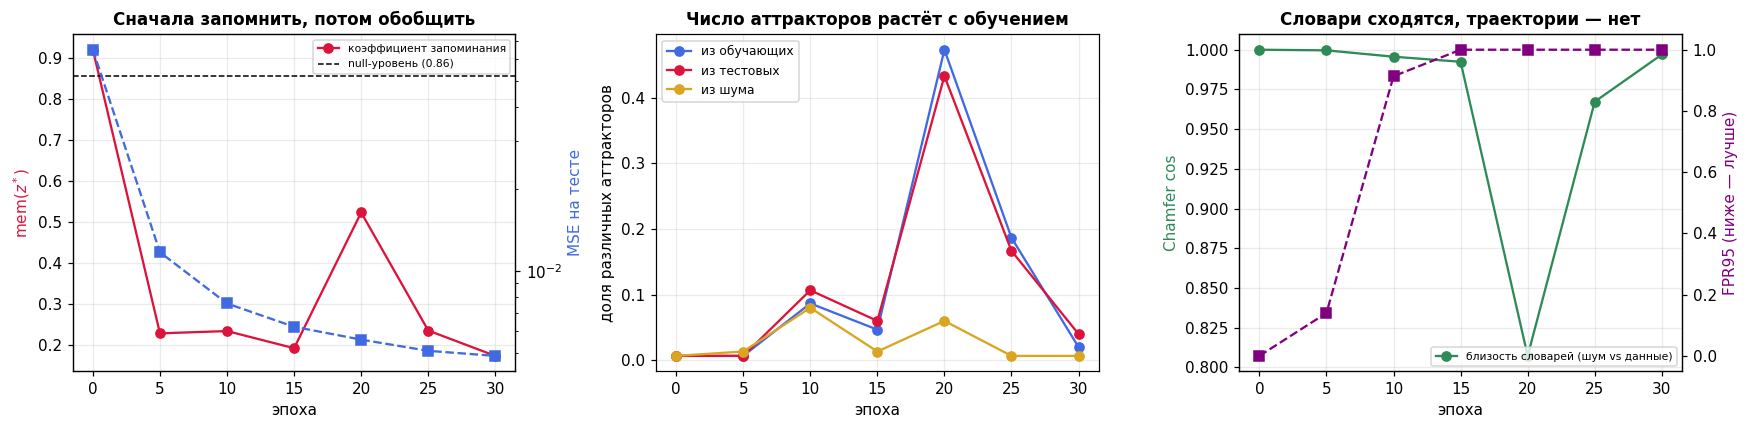

In [23]:
# ── Графики динамики ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

ax = axes[0]
ax.plot(dyn.ep, dyn.mem, "o-", color="crimson", label="коэффициент запоминания")
ax.axhline(null_test, ls="--", c="k", lw=1, label=f"null-уровень ({null_test:.2f})")
ax.set_xlabel("эпоха"); ax.set_ylabel("$\\mathrm{mem}(z^*)$", color="crimson")
ax2 = ax.twinx()
ax2.plot(dyn.ep, dyn.test, "s--", color="royalblue", label="MSE на тесте")
ax2.set_yscale("log"); ax2.set_ylabel("MSE на тесте", color="royalblue")
ax.set_title("Сначала запомнить, потом обобщить", fontweight="bold", fontsize=11)
ax.legend(fontsize=7, loc="upper right"); ax.grid(alpha=0.25)

ax = axes[1]
for col, lb, c in [("n_tr", "из обучающих", "royalblue"), ("n_te", "из тестовых", "crimson"),
                   ("n_noise", "из шума", "goldenrod")]:
    ax.plot(dyn.ep, dyn[col], "o-", color=c, label=lb)
ax.set_xlabel("эпоха"); ax.set_ylabel("доля различных аттракторов")
ax.set_title("Число аттракторов растёт с обучением", fontweight="bold", fontsize=11)
ax.legend(fontsize=8); ax.grid(alpha=0.25)

ax = axes[2]
ax.plot(dyn.ep, dyn.cham, "o-", color="seagreen", label="близость словарей (шум vs данные)")
ax.set_xlabel("эпоха"); ax.set_ylabel("Chamfer cos", color="seagreen")
ax3 = ax.twinx()
ax3.plot(dyn.ep, dyn.fpr95, "s--", color="purple", label="FPR95 траекторий")
ax3.set_ylabel("FPR95 (ниже — лучше)", color="purple")
ax.set_title("Словари сходятся, траектории — нет", fontweight="bold", fontsize=11)
ax.legend(fontsize=7, loc="lower right"); ax.grid(alpha=0.25)

fig.tight_layout()
plt.show()

### **5.1 Что воспроизвелось, а что нет**

**Пункт 1 воспроизвёлся идеально.** На нулевой эпохе доля различных аттракторов равна $1/150$ —
то есть все 150 стартовых точек, откуда бы они ни шли (обучающие данные, тест, шум), приезжают
в **одну и ту же** точку. Необученная сеть — один глобальный аттрактор.

**Пункт 2 воспроизвёлся наполовину.** Коэффициент запоминания на нулевой эпохе действительно
высокий ($0.92$) и падает до $0.23$ уже к пятой эпохе — но от нулевого уровня $0.856$:
превышение составляет всего $+0.06$. 

**Пункты 3 и 4 не воспроизвелись.** Доля различных аттракторов
у нас скачет ($0.007 \to 0.087 \to 0.047 \to 0.473 \to 0.187 \to 0.020$). 
А метрика Chamfer-близости словарей из шума и из данных равна $1.000$ уже на нулевой эпохе и не опускается
ниже $0.81$ за всё обучение. Обе метрики **косинусные**, а в $\mathbb{R}^{64}$ у нашей модели все
аттракторы смотрят почти в одну сторону — та же анизотропия, из-за которой в части 4 склейка по
косинусу схлопнула 300 различных точек в один «аттрактор». 

**Пункт 5 (траектории становятся различимыми, FPR95 падает) воспроизвёлся с обратным знаком:**
FPR95 у нас **растёт** с $0.00$ до $1.00$, а должен падать. Возможно снова из-за структуры данных — за OOD взят равномерный шум. Равномерно-шумная картинка $28\times 28$ после энкодера попадает  **в центр** латентного облака: у неё
нет ни выраженных штрихов, ни структуры, её код близок к среднему коду. А значит, её траектория
проходит **ближе** к аттракторам, чем траектория настоящей цифры, и score по построению
переворачивается. В статье OOD-наборы — это SUN397, Places365, Texture, iNaturalist, то есть
**натуральные картинки**, а гауссов шум используется только как источник стартовых точек для
поиска аттракторов, но никогда как OOD-класс.

> Мораль: **«OOD» задача с требованием аккуратной постановки.**. Объект, который сложнее
> обучающего распределения, и объект, который проще него, ведут себя в векторном поле
> противоположным образом. Любая метрика вида «расстояние до аттракторов» неявно предполагает
> первый случай.

## **Часть 6. Что с этим полем можно делать**

Теория и диагностика — хорошо, но статья предлагает два вполне прикладных применения. Оба
воспроизведём.

### **6.1 Data-free probing: что лежит в весах, если данных нет вообще**

Постановка: Есть предобученная модель. Данных, на которых её учили, у нас нет. Вопрос: можно ли что-то содержательное из весов?

Идея статьи: сэмплируем $Z_n \sim \mathcal{N}(0, I)$, итерируем до нахождения аттракторов и полученный набор объявляем словарём сигналов, после чего смотрим, насколько разреженно им кодируются реальные данные. У авторов это AE Stable Diffusion, 4096 шумовых точек и шесть датасетов и результат: аттракторы выигрывают на всех датасетах.

Мне это воспроизвести не удалось на рассмотренном простом примере и моя гипотеза — опять причина бедности словаря модели и простота постановки. 

### **6.2 OOD-детекция по траекториям**

Вторая задача — определить, пришёл ли объект из того распределения, на котором модель училась.

Идея статьи: у OOD-объекта есть два способа выдать себя и их и проверяем:

1. Его траектория **не сходится** к аттракторам обучающих данных — то есть он вообще в другом
   бассейне.
2. Даже если бассейн общий, он **сходится иначе** — обычно быстрее, потому что снаружи носителя
   данных поле сильнее (мы это видели в части 2: $\|J_f\| \approx 0.25$ вдали и $\approx 1$ на данных).

Чтобы поймать оба случая, берётся **вся траектория**, а не только её конец:

$$\mathrm{score}(z) = \frac{1}{N} \sum_{z_i \in \pi(z)} d\big(z_i, \mathcal{Z}^*_{\text{train}}\big),
\qquad \pi(z) = [z_0, \dots, z_N]$$

Полученная оценка сравнивается с **KNN в пространстве признаков** — средним расстоянием до $K$
ближайших латентов обучающей выборки (адаптация Sun et al., 2022):

$$\mathrm{score}_{\mathrm{KNN}}(z) = \frac{1}{K} \sum_{u \in \mathrm{NN}_K(z,\; \mathcal{Z}_{\text{train}})} d(z, u)$$

Разница между ними: траекторный скор
меряет расстояние до **аттракторов** и вдоль всего пути, а KNN — до **самих
обучающих латентов** и в одной точке. Аттракторы лежат в центре облака, обучающие латенты — по всему облаку.

Обе метрики качества считаются как качество классификации по одной разметке: ID получает метку $0$, OOD — метку $1$.
**AUROC** — вероятность, что случайный OOD-объект получит скор выше случайного ID-объекта
($0.5$ — метод не различает ничего). **FPR95** — берём порог по вероятности, пропускающий 95% своих, и смотрим,
какая доля чужих через него просочилась; чем меньше, тем лучше.

Рассмотрим этот эксперимент. Возьмем как ID — тест MNIST, OOD — FashionMNIST и равномерный шум, модель — наш $k=32$.

In [26]:
# ── OOD-детекция: траектории против KNN ──────────────────────────────
Xf_tr, _, Xf_te, _ = load(10, 2000, fashion=True)      # FashionMNIST как OOD

ae32 = models[32]
with torch.no_grad():
    Ztr32 = ae32.enc(Xtr[:1000])
A_tr32, _ = iterate(ae32, Ztr32.clone(), 300, 1e-5)
A_uniq32 = A_tr32[dedup(A_tr32, 0.99)]
print(f"обучающих аттракторов: {len(A_tr32)} точек → {len(A_uniq32)} различных")

with torch.no_grad():
    Z_id = ae32.enc(Xte)
    Z_fashion = ae32.enc(Xf_te)
    Z_unif = ae32.enc(torch.rand(2000, 1, 28, 28, generator=torch.Generator().manual_seed(3)))

sets = {"MNIST-тест (ID)": Z_id, "FashionMNIST": Z_fashion, "равномерный шум": Z_unif}
traj = {n: traj_score(ae32, Z, A_uniq32) for n, Z in sets.items()}

K = 50
knn = {n: torch.cdist(Z, Ztr32).topk(K, largest=False).values.mean(1).numpy() for n, Z in sets.items()}

print(f"\n{'OOD-набор':>18} | {'траектории':^19} | {'KNN (K=50)':^19}")
print(f"{'':>18} | {'AUROC':>8} {'FPR95':>9} | {'AUROC':>8} {'FPR95':>9}")
ood_rows = []
for ood in ["FashionMNIST", "равномерный шум"]:
    y = np.r_[np.zeros(len(traj["MNIST-тест (ID)"])), np.ones(len(traj[ood]))]
    a_t = roc_auc_score(y, np.r_[traj["MNIST-тест (ID)"], traj[ood]])
    a_k = roc_auc_score(y, np.r_[knn["MNIST-тест (ID)"], knn[ood]])
    f_t = fpr_at_95tpr(traj["MNIST-тест (ID)"], traj[ood])
    f_k = fpr_at_95tpr(knn["MNIST-тест (ID)"], knn[ood])
    print(f"{ood:>18} | {a_t:>8.3f} {f_t:>9.3f} | {a_k:>8.3f} {f_k:>9.3f}")
    ood_rows.append(dict(ood=ood, auroc_traj=a_t, fpr_traj=f_t, auroc_knn=a_k, fpr_knn=f_k))

обучающих аттракторов: 1000 точек → 5 различных

         OOD-набор |     траектории      |     KNN (K=50)     
                   |    AUROC     FPR95 |    AUROC     FPR95
      FashionMNIST |    0.828     0.374 |    0.821     0.528
   равномерный шум |    0.729     0.807 |    0.943     0.517


Посмотрим, что за 5 аттракторов, на которых мы все изеряем.

 аттрактор   стартов    норма   cos к ближайшей обучающей
      z*_1       405     46.7                       0.316
      z*_2       249     45.5                       0.304
      z*_3       333     21.7                       0.155
      z*_4         5     36.1                       0.402
      z*_5         8     41.5                       0.334

для сравнения: медианная норма латентов данных 49.7; null-уровень max-косинуса (невиданная картинка → обучающая) на MNIST ≈ 0.86


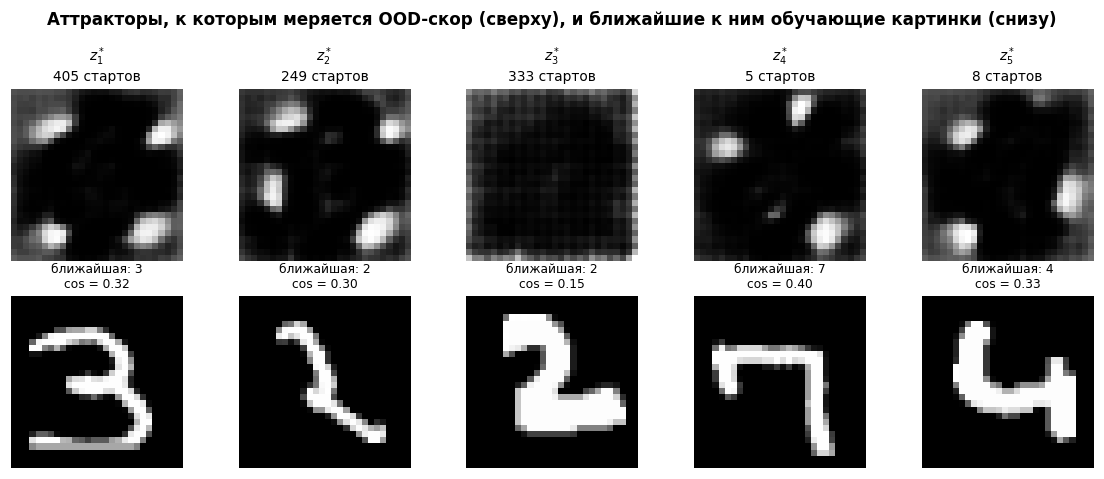

In [ ]:
# ── Что за пять точек, к которым всё меряется?
# Весь траекторный скор — это расстояние до A_uniq32. Посмотрим на них:
# сколько стартов пришло в каждую, где они лежат и на что похожи.
lab32 = torch.cdist(A_tr32, A_uniq32).argmin(1)
sizes32 = torch.bincount(lab32, minlength=len(A_uniq32))

with torch.no_grad():
    X_star32 = ae32.dec(A_uniq32)
sims32 = F.normalize(X_star32.flatten(1), dim=1) @ F.normalize(Xtr.flatten(1), dim=1).T
best32 = sims32.max(1)

print(f"{'аттрактор':>10} {'стартов':>9} {'норма':>8} {'cos к ближайшей обучающей':>27}")
for i in range(len(A_uniq32)):
    print(f"{'z*_' + str(i + 1):>10} {sizes32[i].item():>9} "
          f"{A_uniq32[i].norm():>8.1f} {best32.values[i]:>27.3f}")
print(f"\nдля сравнения: медианная норма латентов данных {Ztr32.norm(dim=1).median():.1f}; "
      f"null-уровень max-косинуса (невиданная картинка → обучающая) на MNIST ≈ 0.86")

fig, ax = plt.subplots(2, len(A_uniq32), figsize=(2.1 * len(A_uniq32), 4.4))
for i in range(len(A_uniq32)):
    ax[0, i].imshow(X_star32[i, 0], cmap="gray"); ax[0, i].axis("off")
    ax[0, i].set_title(f"$z^*_{i + 1}$\n{sizes32[i].item()} стартов", fontsize=9)
    j = int(best32.indices[i])
    ax[1, i].imshow(Xtr[j, 0], cmap="gray"); ax[1, i].axis("off")
    ax[1, i].set_title(f"ближайшая: {ytr[j]}\ncos = {best32.values[i]:.2f}", fontsize=8)
fig.suptitle("Аттракторы, к которым меряется OOD-скор (сверху), и ближайшие к ним обучающие картинки (снизу)",
             fontweight="bold", fontsize=11)
fig.tight_layout()
plt.show()

Декодированные аттракторы — размытые пятна и текстуры,
косинус к ближайшей обучающей картинке $0.15$–$0.40$ при null-уровне $0.86$. То есть они непохожи на MNIST сильнее, чем равномерный шум (у того null $0.52$).

> Отсюда видим, что скор должен давать корректный результат, только если аттракторы описывают данные и лежат **внутри** облака. Если это не верно — выйдет кривовато. 

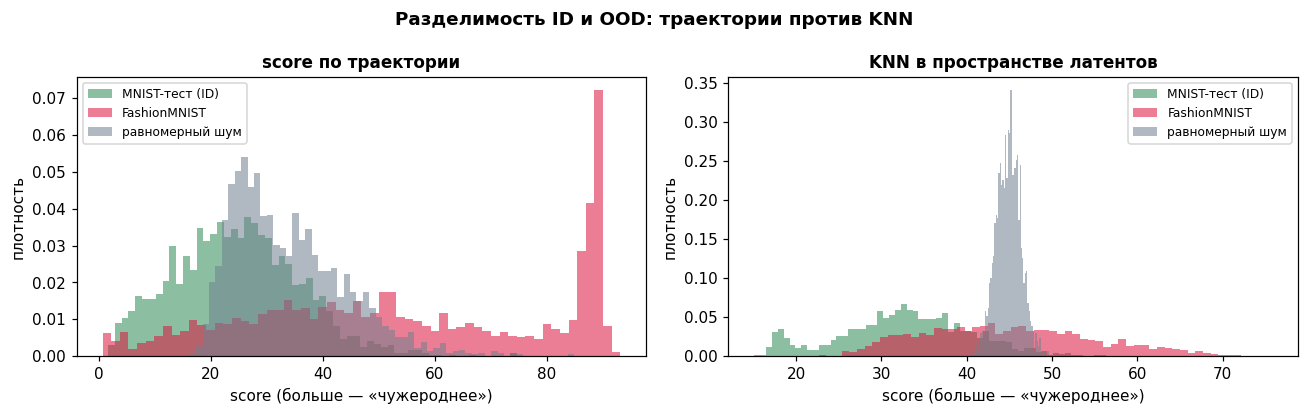

In [27]:
# ── Картинка: распределения скоров ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (scores, title) in zip(axes, [(traj, "score по траектории"), (knn, "KNN в пространстве латентов")]):
    for n, c in zip(sets, ["seagreen", "crimson", "slategray"]):
        v = scores[n]
        ax.hist(v, bins=60, alpha=0.55, label=n, color=c, density=True)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("score (больше — «чужероднее»)"); ax.set_ylabel("плотность")
    ax.legend(fontsize=8)
fig.suptitle("Разделимость ID и OOD: траектории против KNN", fontweight="bold")
fig.tight_layout()
plt.show()

**Что видим.** По горизонтали — значение скора, по вертикали — плотность.
Хорошая картинка должна выглядеть выглядит как две несовпадающие горки: зелёная (свои) слева, цветная (чужие)
справа. Чем меньше они перекрываются, тем выше AUROC.

- **Слева, траекторный скор.** Зелёная и серая горки сидят друг на друге — шум по этому скору
  неотличим от настоящих цифр. Красная сдвинута
  вправо и имеет отдельный пик у правого края: часть FashionMNIST уезжает совсем далеко от
  аттракторов и там и остаётся.
- **Справа, KNN.** Серая горка превратилась в узкий пик, стоящий правее зелёной, — шум отлично
  отделяется. Красная широкая и сильно перекрывается с зелёной.

> **Почему плотности выглядят так по-разному.**  Два скора — это две разные величины в разных единицах: слева среднее расстояние до пяти аттракторов вдоль тридцати шагов, справа — среднее асстояние до пятидесяти ближайших обучающих латентов в одной точке. 
> Диапазоны у них разные (0–95 против 15–70), а построение нормирует площадь каждой горки на единицу.
> Поэтому узкое распределение рисуется высоким, широкое — низким, и высоту столбиков между панелями сравнивать нельзя — только форму и перекрытие.
> Узкий серый пик справа следует из того, что две тысячи равномерно-шумных картинок статистически одинаковы, у них нет ни штрихов, ни структуры, поэтому и кодируются они почти в одну точку — и расстояния до обучающей выборки у них получаются почти одинаковыми. 
> Слева тот же шум размазан шире, потому что траекторный скор усредняет по тридцати шагам, а на этом пути точки успевают разойтись.
> На сами метрики масштаб не влияет: и AUROC, и FPR95 зависят только от порядка скоров, а не от их абсолютных значений.

**Числа:**

**FashionMNIST (OOD).** Траекторный score: AUROC $0.828$, FPR95 $0.374$.
KNN: AUROC $0.821$, FPR95 $0.528$. По AUROC методы практически сравнялись, а вот траектории заметно лучше: $0.374$ против $0.528$. 

**Равномерный шум.** Траекторный score: AUROC $0.729$, FPR95 $0.807$. KNN: AUROC $0.943$, FPR95 $0.517$. Здесь траектории **проигрывают** с большим отрывом.

Причина скорее всего снова в простоте: равномерно-шумная картинка $28\times 28$ — это объект **проще** обучающего распределения. Для задачи у таких данных нет ни штрихов, ни структуры, и энкодер отправляет её в **центр** латентного облака.

А центр — это как раз то место, где живут аттракторы. Значит, траектория шума проходит **ближе** к обучающим аттракторам, чем траектория настоящей цифры, и score, устроенный как «расстояние до аттракторов», переворачивается знаком. Заметьте также, какие страшные вышли самы аттракторы: они не инофрмативны, хотя ближние точки различны и соответствуют конкретным классам. 

KNN такой проблемы не имеет: он меряет расстояние до **самих обучающих латентов**, а не до аттракторов, а обучающие латенты лежат не в центре, а в оболочке вокруг него.

> **Примечание:**
> траекторный score отвечает не совсем на вопрос «этот объект из другого распределения?», а на вопрос
> «этот объект **дальше от мод** выученного распределения?». Для натуральных OOD-наборов эти два вопроса совпадают.
> Для вырожденных входов — шума, константных картинок, сильно размытых изображений (и скорее всего — для остсязательных тоже) — они
> противоположны, и метод может дать неверный ответ.

## **Часть 7. Границы применимости**

Итак, мы рассмотрели эксперимент, позволяющий изучить внутреннюю картину мира модели на основе идей из динамических система. Подход не общий и валиден только для автоэнкодеров, у дискриминативной модели — классификатора, энкодера-онли, next-token-предсказателя — его нет. 

В статье это тоже рассмотрено и даже почти успешно, но с границами интерпретации экспериментов. А именно, описано, что: 

- можно обучить декодер поверх замороженного энкодера (в Appendix B.8.1 так сделано для DINOv2 и SigLIP2); 
- можно работать в выходном пространстве, определив поле как остаток ; 
- можно итерировать весь residual stream целиком (в Appendix B.8.2 — для Qwen3-0.6B и SmolLM2-1.7B). 

Из других ограничений, справедливо также то, что пока мы рассматривали эксперимент в простом сетапе, мы получили не полную воспроизводимость (хотя основные геометрические паттерн воспроизвелись отлично, практические — не совсем точно и осмысленно в силу простоты данных). 

Отсюда важно забрать с собой то, что когда пытаетесь повторить сильные результаты — будьте уверенны о близостях постановок вашего и рассматриваемого случая. 

На этом у меня всё и вы молодцы! 
Спасибо, что дочитали! Надеюсь, вы повторите что-то у себя или просто получили удовольствие от красоты теории.

До новых встреч, друзья!

Если понравилось, как всегда зову в:
- [Telegram Blog, ru](https://t.me/jdata_blog)
- [Другие туториалы]()
- [LinkedIn](https://www.linkedin.com/in/sabrina-sadiekh)